<a href="https://colab.research.google.com/github/neuish/Vitamin_D_Project/blob/main/Vitamin_D_Prediction_Full_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Problem Statement

This project aims to develop a Logistic regression model to analyze Vitamn D Predictions


In [129]:
import sys
# Install necessary packages
!{sys.executable} -m pip install catboost pytorch-tabnet


In [130]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from math import pi
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
import shap
import warnings
warnings.filterwarnings("ignore")

# 2. Data Loading and Describing

In [131]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [132]:
df = pd.read_csv('/content/drive/MyDrive/Logistic Regression/Vitamin_D_Dataset.csv')

In [133]:
# first few rows of data

df.head()

,age,bmi,sun_hours_per_day,screen_time_hours,calcium_intake_mg,vitaminD_supplement_dose_IU,latitude_deg,outdoor_activity_minutes,diet_score,sleep_hours,...,season,physical_activity_level,diet_type,socioeconomic_status,education_level,smoking_status,alcohol_use,urban_rural,vitaminD_ng_ml,deficient_label
0,48,24.704992,5.388847,7.822940,481.870343,0,23.387283,53.132966,5.598435,7.896034,...,Winter,Low,Non-veg,Middle,Graduate,Non-smoker,Yes,Urban,16.489554,1
1,36,18.883132,2.578413,6.919658,967.785209,1000,33.393709,81.746428,3.278181,7.335898,...,Monsoon,Moderate,Non-veg,Middle,Secondary,Non-smoker,No,Rural,16.872776,1
2,48,22.202328,6.913801,3.833820,878.614331,400,20.668296,70.002850,5.751364,4.490197,...,Spring,Low,Non-veg,Low,Graduate,Non-smoker,Yes,Urban,23.934443,0
3,30,24.658394,7.489518,7.155493,300.000000,0,32.977726,63.822784,8.216929,7.508073,...,Monsoon,Moderate,Non-veg,Middle,Postgraduate,Non-smoker,No,Urban,21.460801,0
4,74,25.547911,2.403983,8.790671,894.374742,800,17.192737,69.515129,4.040100,8.651286,...,Monsoon,Low,Mixed,Middle,Postgraduate,Smoker,Yes,Urban,14.009061,1


In [134]:
#  data information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          10000 non-null  int64  
 1   bmi                          10000 non-null  float64
 2   sun_hours_per_day            10000 non-null  float64
 3   screen_time_hours            10000 non-null  float64
 4   calcium_intake_mg            10000 non-null  float64
 5   vitaminD_supplement_dose_IU  10000 non-null  int64  
 6   latitude_deg                 10000 non-null  float64
 7   outdoor_activity_minutes     10000 non-null  float64
 8   diet_score                   10000 non-null  float64
 9   sleep_hours                  10000 non-null  float64
 10  cholesterol_level_mgdl       10000 non-null  float64
 11  body_fat_percentage          10000 non-null  float64
 12  serum_calcium_mgdl           10000 non-null  float64
 13  sex              

In [135]:
# describing data


df.describe()

,age,bmi,sun_hours_per_day,screen_time_hours,calcium_intake_mg,vitaminD_supplement_dose_IU,latitude_deg,outdoor_activity_minutes,diet_score,sleep_hours,cholesterol_level_mgdl,body_fat_percentage,serum_calcium_mgdl,vitaminD_ng_ml,deficient_label
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,48.531700,23.990007,4.270745,5.495023,705.113976,491.660000,22.546853,60.035959,5.972677,6.964473,179.564273,24.961340,9.194492,21.316680,0.405600
std,17.824247,3.914229,2.171903,2.602268,237.303070,526.427732,8.365684,29.310643,1.975767,1.465492,30.006006,6.848415,0.500895,5.203584,0.491032
min,18.000000,16.000000,0.500669,1.000854,300.000000,0.000000,8.000600,0.000000,0.000000,3.000000,100.000000,10.000000,7.500000,5.000000,0.000000
25%,33.000000,21.251287,2.397303,3.265333,532.827692,0.000000,15.414647,39.486387,4.622339,5.950184,159.180573,20.197551,8.854299,17.681899,0.000000
50%,49.000000,23.954753,4.269302,5.449168,703.407416,400.000000,22.470903,59.946250,5.996280,6.978372,179.346633,24.937536,9.202850,21.212827,0.000000
75%,64.000000,26.681251,6.154501,7.738790,868.196356,800.000000,29.787257,79.909425,7.351095,8.008932,199.980467,29.616033,9.536056,24.942650,1.000000
max,79.000000,38.862701,7.999071,9.999904,1500.000000,2000.000000,36.992565,166.688705,10.000000,10.000000,280.000000,45.000000,11.000000,40.133243,1.000000


## 2.1. Data Cleaning and treating

In [136]:
# count null

df.isnull().sum()


,0
age,0
bmi,0
sun_hours_per_day,0
screen_time_hours,0
calcium_intake_mg,0
vitaminD_supplement_dose_IU,0
latitude_deg,0
outdoor_activity_minutes,0
diet_score,0
sleep_hours,0


In [137]:
# Drop rows with any null values
df.dropna(inplace=True)


In [138]:
# Count duplicates based on all columns
duplicate_rows = df[df.duplicated()]
num_duplicates = len(duplicate_rows)
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


In [139]:
df.columns = [
    'age',
    'bmi',
    'sun_hours_per_day',
    'screen_time_hours',
    'calcium_intake_mg',
    'vitamin_d_supplement_iu',
    'latitude_deg',
    'outdoor_activity_minutes',
    'diet_score',
    'sleep_hours',
    'cholesterol_mg_dl',
    'body_fat_percentage',
    'serum_calcium_mg_dl',
    'sex',
    'skin_tone',
    'clothing_coverage',
    'season',
    'physical_activity_level',
    'diet_type',
    'socioeconomic_status',
    'education_level',
    'smoking_status',
    'alcohol_use',
    'urban_rural',
    'vitamin_d_ng_ml',
    'deficient_label'
]


In [140]:
print(f"Number of rows in the DataFrame: {df.shape[0]}")

Number of rows in the DataFrame: 10000


In [141]:
# Rename the specific column
df.rename(columns={'deficient_label': 'deficient'}, inplace=True)

# Check the change
print(df.columns)


Index(['age', 'bmi', 'sun_hours_per_day', 'screen_time_hours',
       'calcium_intake_mg', 'vitamin_d_supplement_iu', 'latitude_deg',
       'outdoor_activity_minutes', 'diet_score', 'sleep_hours',
       'cholesterol_mg_dl', 'body_fat_percentage', 'serum_calcium_mg_dl',
       'sex', 'skin_tone', 'clothing_coverage', 'season',
       'physical_activity_level', 'diet_type', 'socioeconomic_status',
       'education_level', 'smoking_status', 'alcohol_use', 'urban_rural',
       'vitamin_d_ng_ml', 'deficient'],
      dtype='object')


In [142]:
print(df.head())


   age        bmi  sun_hours_per_day  screen_time_hours  calcium_intake_mg  \
0   48  24.704992           5.388847           7.822940         481.870343   
1   36  18.883132           2.578413           6.919658         967.785209   
2   48  22.202328           6.913801           3.833820         878.614331   
3   30  24.658394           7.489518           7.155493         300.000000   
4   74  25.547911           2.403983           8.790671         894.374742   

   vitamin_d_supplement_iu  latitude_deg  outdoor_activity_minutes  \
0                        0     23.387283                 53.132966   
1                     1000     33.393709                 81.746428   
2                      400     20.668296                 70.002850   
3                        0     32.977726                 63.822784   
4                      800     17.192737                 69.515129   

   diet_score  sleep_hours  ...   season  physical_activity_level  diet_type  \
0    5.598435     7.896034  ..

# Visualization on Vitamin D Deficiency



1.  Sun Hours vs Vitamin D Level-  This is the strongest positive correlation.
2. Suppliment vs defeciency - stringest negative correlation





1. Vitamin D Distribution (Population Health Profile)

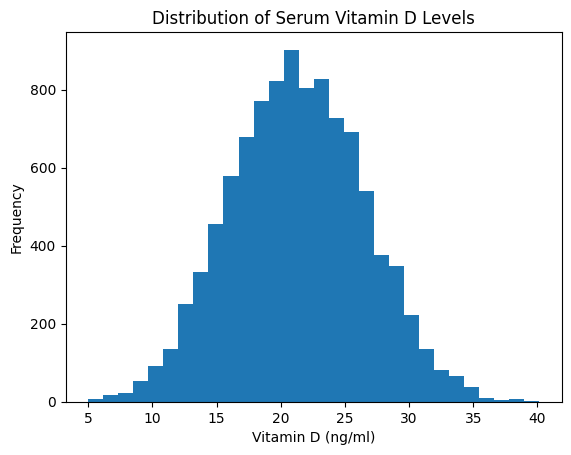

In [143]:
plt.figure()
plt.hist(df['vitamin_d_ng_ml'], bins=30)
plt.title('Distribution of Serum Vitamin D Levels')
plt.xlabel('Vitamin D (ng/ml)')
plt.ylabel('Frequency')
plt.show()

2. Vitamin D vs Deficiency Status (Core Outcome Separation)

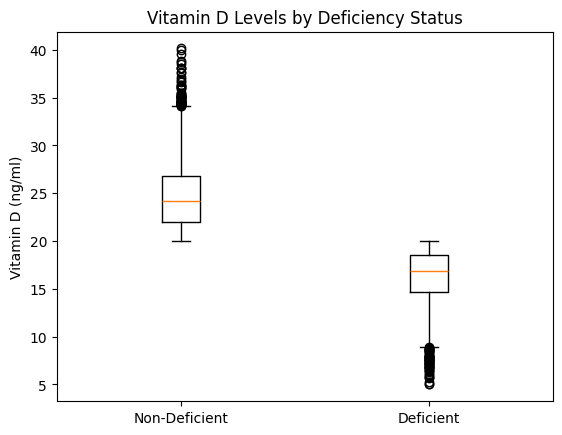

In [144]:
plt.figure()
plt.boxplot([
    df[df['deficient'] == 0]['vitamin_d_ng_ml'],
    df[df['deficient'] == 1]['vitamin_d_ng_ml']
])
plt.xticks([1, 2], ['Non-Deficient', 'Deficient'])
plt.title('Vitamin D Levels by Deficiency Status')
plt.ylabel('Vitamin D (ng/ml)')
plt.show()

3. Sun Exposure vs Vitamin D (Primary Biological Driver)

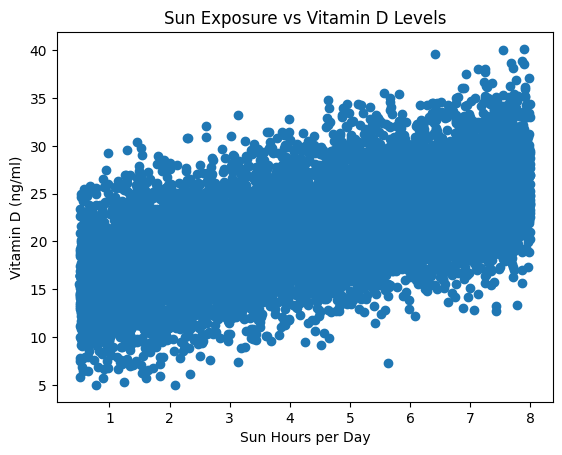

In [145]:
plt.figure()
plt.scatter(df['sun_hours_per_day'], df['vitamin_d_ng_ml'])
plt.title('Sun Exposure vs Vitamin D Levels')
plt.xlabel('Sun Hours per Day')
plt.ylabel('Vitamin D (ng/ml)')
plt.show()

4. Latitude Effect (Geographical Determinant)

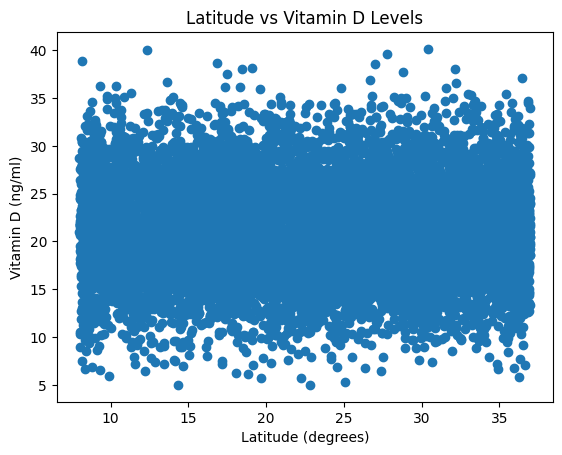

In [146]:
plt.figure()
plt.scatter(df['latitude_deg'], df['vitamin_d_ng_ml'])
plt.title('Latitude vs Vitamin D Levels')
plt.xlabel('Latitude (degrees)')
plt.ylabel('Vitamin D (ng/ml)')
plt.show()

5. Screen Time vs Vitamin D (Modern Lifestyle Factor)

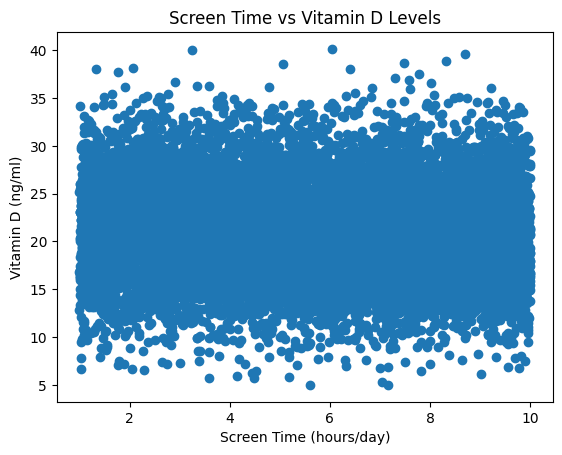

In [147]:
plt.figure()
plt.scatter(df['screen_time_hours'], df['vitamin_d_ng_ml'])
plt.title('Screen Time vs Vitamin D Levels')
plt.xlabel('Screen Time (hours/day)')
plt.ylabel('Vitamin D (ng/ml)')
plt.show()

6. Outdoor Activity vs Vitamin D (Behavioral Exposure Factor)

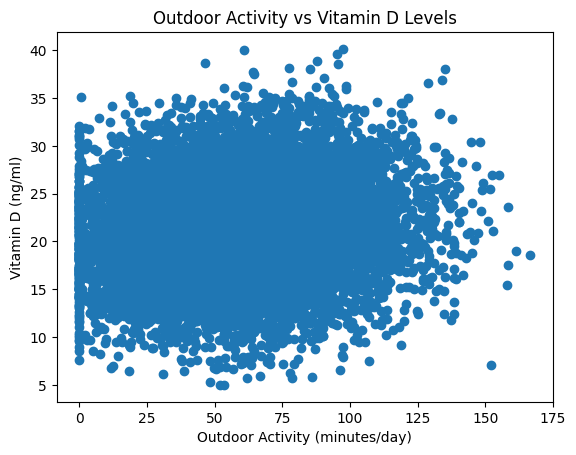

In [148]:
plt.figure()
plt.scatter(df['outdoor_activity_minutes'], df['vitamin_d_ng_ml'])
plt.title('Outdoor Activity vs Vitamin D Levels')
plt.xlabel('Outdoor Activity (minutes/day)')
plt.ylabel('Vitamin D (ng/ml)')
plt.show()

##Feature Engineering

In [149]:
df = df.drop('vitamin_d_ng_ml', axis=1)
print(df.head())

   age        bmi  sun_hours_per_day  screen_time_hours  calcium_intake_mg  \
0   48  24.704992           5.388847           7.822940         481.870343   
1   36  18.883132           2.578413           6.919658         967.785209   
2   48  22.202328           6.913801           3.833820         878.614331   
3   30  24.658394           7.489518           7.155493         300.000000   
4   74  25.547911           2.403983           8.790671         894.374742   

   vitamin_d_supplement_iu  latitude_deg  outdoor_activity_minutes  \
0                        0     23.387283                 53.132966   
1                     1000     33.393709                 81.746428   
2                      400     20.668296                 70.002850   
3                        0     32.977726                 63.822784   
4                      800     17.192737                 69.515129   

   diet_score  sleep_hours  ...  clothing_coverage   season  \
0    5.598435     7.896034  ...                

In [150]:
print(df['age'].unique())
print(df['deficient'].unique())


[48 36 30 74 21 37 50 40 55 28 32 51 58 41 65 38 34 18 71 54 43 35 73 29
 63 46 27 45 31 69 44 59 60 78 33 49 70 23 39 25 56 42 68 26 72 57 79 52
 77 67 22 64 75 19 53 66 24 47 61 20 62 76]
[1 0]


In [151]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Categorical columns identified:", categorical_cols)


Categorical columns identified: ['sex', 'skin_tone', 'clothing_coverage', 'season', 'physical_activity_level', 'diet_type', 'socioeconomic_status', 'education_level', 'smoking_status', 'alcohol_use', 'urban_rural']


In [152]:
df['deficient'] = df['deficient'].astype('object')
print(f"Data type of 'deficient' column after conversion: {df['deficient'].dtype}")

Data type of 'deficient' column after conversion: object


In [153]:
continuous_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Continuous Columns:", continuous_cols)
print("\nCategorical Columns:", categorical_cols)

Continuous Columns: ['age', 'bmi', 'sun_hours_per_day', 'screen_time_hours', 'calcium_intake_mg', 'vitamin_d_supplement_iu', 'latitude_deg', 'outdoor_activity_minutes', 'diet_score', 'sleep_hours', 'cholesterol_mg_dl', 'body_fat_percentage', 'serum_calcium_mg_dl']

Categorical Columns: ['sex', 'skin_tone', 'clothing_coverage', 'season', 'physical_activity_level', 'diet_type', 'socioeconomic_status', 'education_level', 'smoking_status', 'alcohol_use', 'urban_rural', 'deficient']


In [154]:
categorical_cols_to_encode = ['sex', 'skin_tone', 'clothing_coverage', 'season', 'physical_activity_level', 'diet_type', 'socioeconomic_status', 'education_level', 'smoking_status', 'alcohol_use', 'urban_rural']

df_encoded = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

columns_to_print = ['sex_Male', 'skin_tone_Fair', 'skin_tone_Medium', 'clothing_coverage_Low', 'clothing_coverage_Medium', 'season_Monsoon', 'season_Spring', 'season_Summer', 'physical_activity_level_Moderate', 'physical_activity_level_Sedentary', 'diet_type_Non-veg', 'diet_type_Veg', 'socioeconomic_status_Low', 'socioeconomic_status_Middle', 'education_level_Postgraduate', 'education_level_Secondary', 'smoking_status_Smoker', 'alcohol_use_Yes', 'urban_rural_Urban']

# Filter out columns that might not exist in df_encoded due to drop_first=True or other reasons
existing_columns_to_print = [col for col in columns_to_print if col in df_encoded.columns]

# Print only the existing columns
print(df_encoded[existing_columns_to_print].head())

   sex_Male  skin_tone_Medium  clothing_coverage_Low  \
0     False              True                   True   
1      True             False                   True   
2      True             False                  False   
3     False              True                  False   
4     False              True                  False   

   clothing_coverage_Medium  season_Spring  season_Summer  \
0                     False          False          False   
1                     False          False          False   
2                     False           True          False   
3                     False          False          False   
4                     False          False          False   

   physical_activity_level_Moderate  diet_type_Non-veg  diet_type_Veg  \
0                             False               True          False   
1                              True               True          False   
2                             False               True          False   
3   

In [155]:
for col in df_encoded.select_dtypes(include='bool').columns:
    df_encoded[col] = df_encoded[col].astype(int)

print("DataFrame after converting boolean columns to integers:")
print(df_encoded[existing_columns_to_print].head())

DataFrame after converting boolean columns to integers:
   sex_Male  skin_tone_Medium  clothing_coverage_Low  \
0         0                 1                      1   
1         1                 0                      1   
2         1                 0                      0   
3         0                 1                      0   
4         0                 1                      0   

   clothing_coverage_Medium  season_Spring  season_Summer  \
0                         0              0              0   
1                         0              0              0   
2                         0              1              0   
3                         0              0              0   
4                         0              0              0   

   physical_activity_level_Moderate  diet_type_Non-veg  diet_type_Veg  \
0                                 0                  1              0   
1                                 1                  1              0   
2                    

Grouping Age and Vitdlebel IU

In [156]:
# Define bins and labels for Age Group (already defined in kernel state)
age_bins = [0, 20, 30, 40, 50, 60, 70, float('inf')]
age_labels = ['Below 20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']

# Define bins and labels for Vitamin D Supplement IU (already defined in kernel state)
delay_bins = [0, 400, 800, 1000, 2000, float('inf')]
delay_labels = ['0', '400', '800', '1000', '2000+']

# Create 'Age_Group' column based on bins
df['Age_Group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

# Create 'VitaminD_Supplement_Group' column based on bins
df['VitaminD_Supplement_Group'] = pd.cut(df['vitamin_d_supplement_iu'], bins=delay_bins, labels=delay_labels, right=False)

print("DataFrame after adding Age_Group and VitaminD_Supplement_Group:")
print(df[['age', 'Age_Group', 'vitamin_d_supplement_iu', 'VitaminD_Supplement_Group']].head())

DataFrame after adding Age_Group and VitaminD_Supplement_Group:
   age Age_Group  vitamin_d_supplement_iu VitaminD_Supplement_Group
0   48     40-49                        0                         0
1   36     30-39                     1000                      1000
2   48     40-49                      400                       400
3   30     30-39                        0                         0
4   74       70+                      800                       800


In [157]:
print(f"Data type of 'Age_Group': {df['Age_Group'].dtype}")
print(f"Unique values in 'Age_Group': {df['Age_Group'].unique().tolist()}")
print(f"\nData type of 'VitaminD_Supplement_Group': {df['VitaminD_Supplement_Group'].dtype}")
print(f"Unique values in 'VitaminD_Supplement_Group': {df['VitaminD_Supplement_Group'].unique().tolist()}")

Data type of 'Age_Group': category
Unique values in 'Age_Group': ['40-49', '30-39', '70+', '20-29', '50-59', '60-69', 'Below 20']

Data type of 'VitaminD_Supplement_Group': category
Unique values in 'VitaminD_Supplement_Group': ['0', '1000', '400', '800', '2000+']


In [158]:
# One-hot encode 'Age_Group' and 'VitaminD_Supplement_Group'
df_age_vitd_encoded = pd.get_dummies(df[['Age_Group', 'VitaminD_Supplement_Group']], drop_first=True)

# Convert boolean columns to integers
for col in df_age_vitd_encoded.select_dtypes(include='bool').columns:
    df_age_vitd_encoded[col] = df_age_vitd_encoded[col].astype(int)

# Merge with df_encoded
df_encoded = pd.concat([df_encoded, df_age_vitd_encoded], axis=1)

print("Head of df_encoded after adding one-hot encoded Age_Group and VitaminD_Supplement_Group:")
print(df_encoded.head())

Head of df_encoded after adding one-hot encoded Age_Group and VitaminD_Supplement_Group:
   age        bmi  sun_hours_per_day  screen_time_hours  calcium_intake_mg  \
0   48  24.704992           5.388847           7.822940         481.870343   
1   36  18.883132           2.578413           6.919658         967.785209   
2   48  22.202328           6.913801           3.833820         878.614331   
3   30  24.658394           7.489518           7.155493         300.000000   
4   74  25.547911           2.403983           8.790671         894.374742   

   vitamin_d_supplement_iu  latitude_deg  outdoor_activity_minutes  \
0                        0     23.387283                 53.132966   
1                     1000     33.393709                 81.746428   
2                      400     20.668296                 70.002850   
3                        0     32.977726                 63.822784   
4                      800     17.192737                 69.515129   

   diet_score  sleep_

Scaling and Normalization of Continuous columns

In [159]:
columns_to_scale = [
    'bmi', 'sun_hours_per_day', 'screen_time_hours',
    'calcium_intake_mg', 'latitude_deg', 'outdoor_activity_minutes',
    'diet_score', 'sleep_hours', 'cholesterol_mg_dl',
    'body_fat_percentage', 'serum_calcium_mg_dl'
]

In [160]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 43 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               10000 non-null  int64  
 1   bmi                               10000 non-null  float64
 2   sun_hours_per_day                 10000 non-null  float64
 3   screen_time_hours                 10000 non-null  float64
 4   calcium_intake_mg                 10000 non-null  float64
 5   vitamin_d_supplement_iu           10000 non-null  int64  
 6   latitude_deg                      10000 non-null  float64
 7   outdoor_activity_minutes          10000 non-null  float64
 8   diet_score                        10000 non-null  float64
 9   sleep_hours                       10000 non-null  float64
 10  cholesterol_mg_dl                 10000 non-null  float64
 11  body_fat_percentage               10000 non-null  float64
 12  serum

In [161]:
df_encoded = df_encoded.drop(columns=['age', 'vitamin_d_supplement_iu'])
print("DataFrame after dropping 'age' and 'vitamin_d_supplement_iu':")
print(df_encoded.head())

DataFrame after dropping 'age' and 'vitamin_d_supplement_iu':
         bmi  sun_hours_per_day  screen_time_hours  calcium_intake_mg  \
0  24.704992           5.388847           7.822940         481.870343   
1  18.883132           2.578413           6.919658         967.785209   
2  22.202328           6.913801           3.833820         878.614331   
3  24.658394           7.489518           7.155493         300.000000   
4  25.547911           2.403983           8.790671         894.374742   

   latitude_deg  outdoor_activity_minutes  diet_score  sleep_hours  \
0     23.387283                 53.132966    5.598435     7.896034   
1     33.393709                 81.746428    3.278181     7.335898   
2     20.668296                 70.002850    5.751364     4.490197   
3     32.977726                 63.822784    8.216929     7.508073   
4     17.192737                 69.515129    4.040100     8.651286   

   cholesterol_mg_dl  body_fat_percentage  ...  Age_Group_20-29  \
0         2

In [162]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   bmi                               10000 non-null  float64
 1   sun_hours_per_day                 10000 non-null  float64
 2   screen_time_hours                 10000 non-null  float64
 3   calcium_intake_mg                 10000 non-null  float64
 4   latitude_deg                      10000 non-null  float64
 5   outdoor_activity_minutes          10000 non-null  float64
 6   diet_score                        10000 non-null  float64
 7   sleep_hours                       10000 non-null  float64
 8   cholesterol_mg_dl                 10000 non-null  float64
 9   body_fat_percentage               10000 non-null  float64
 10  serum_calcium_mg_dl               10000 non-null  float64
 11  deficient                         10000 non-null  object 
 12  sex_M

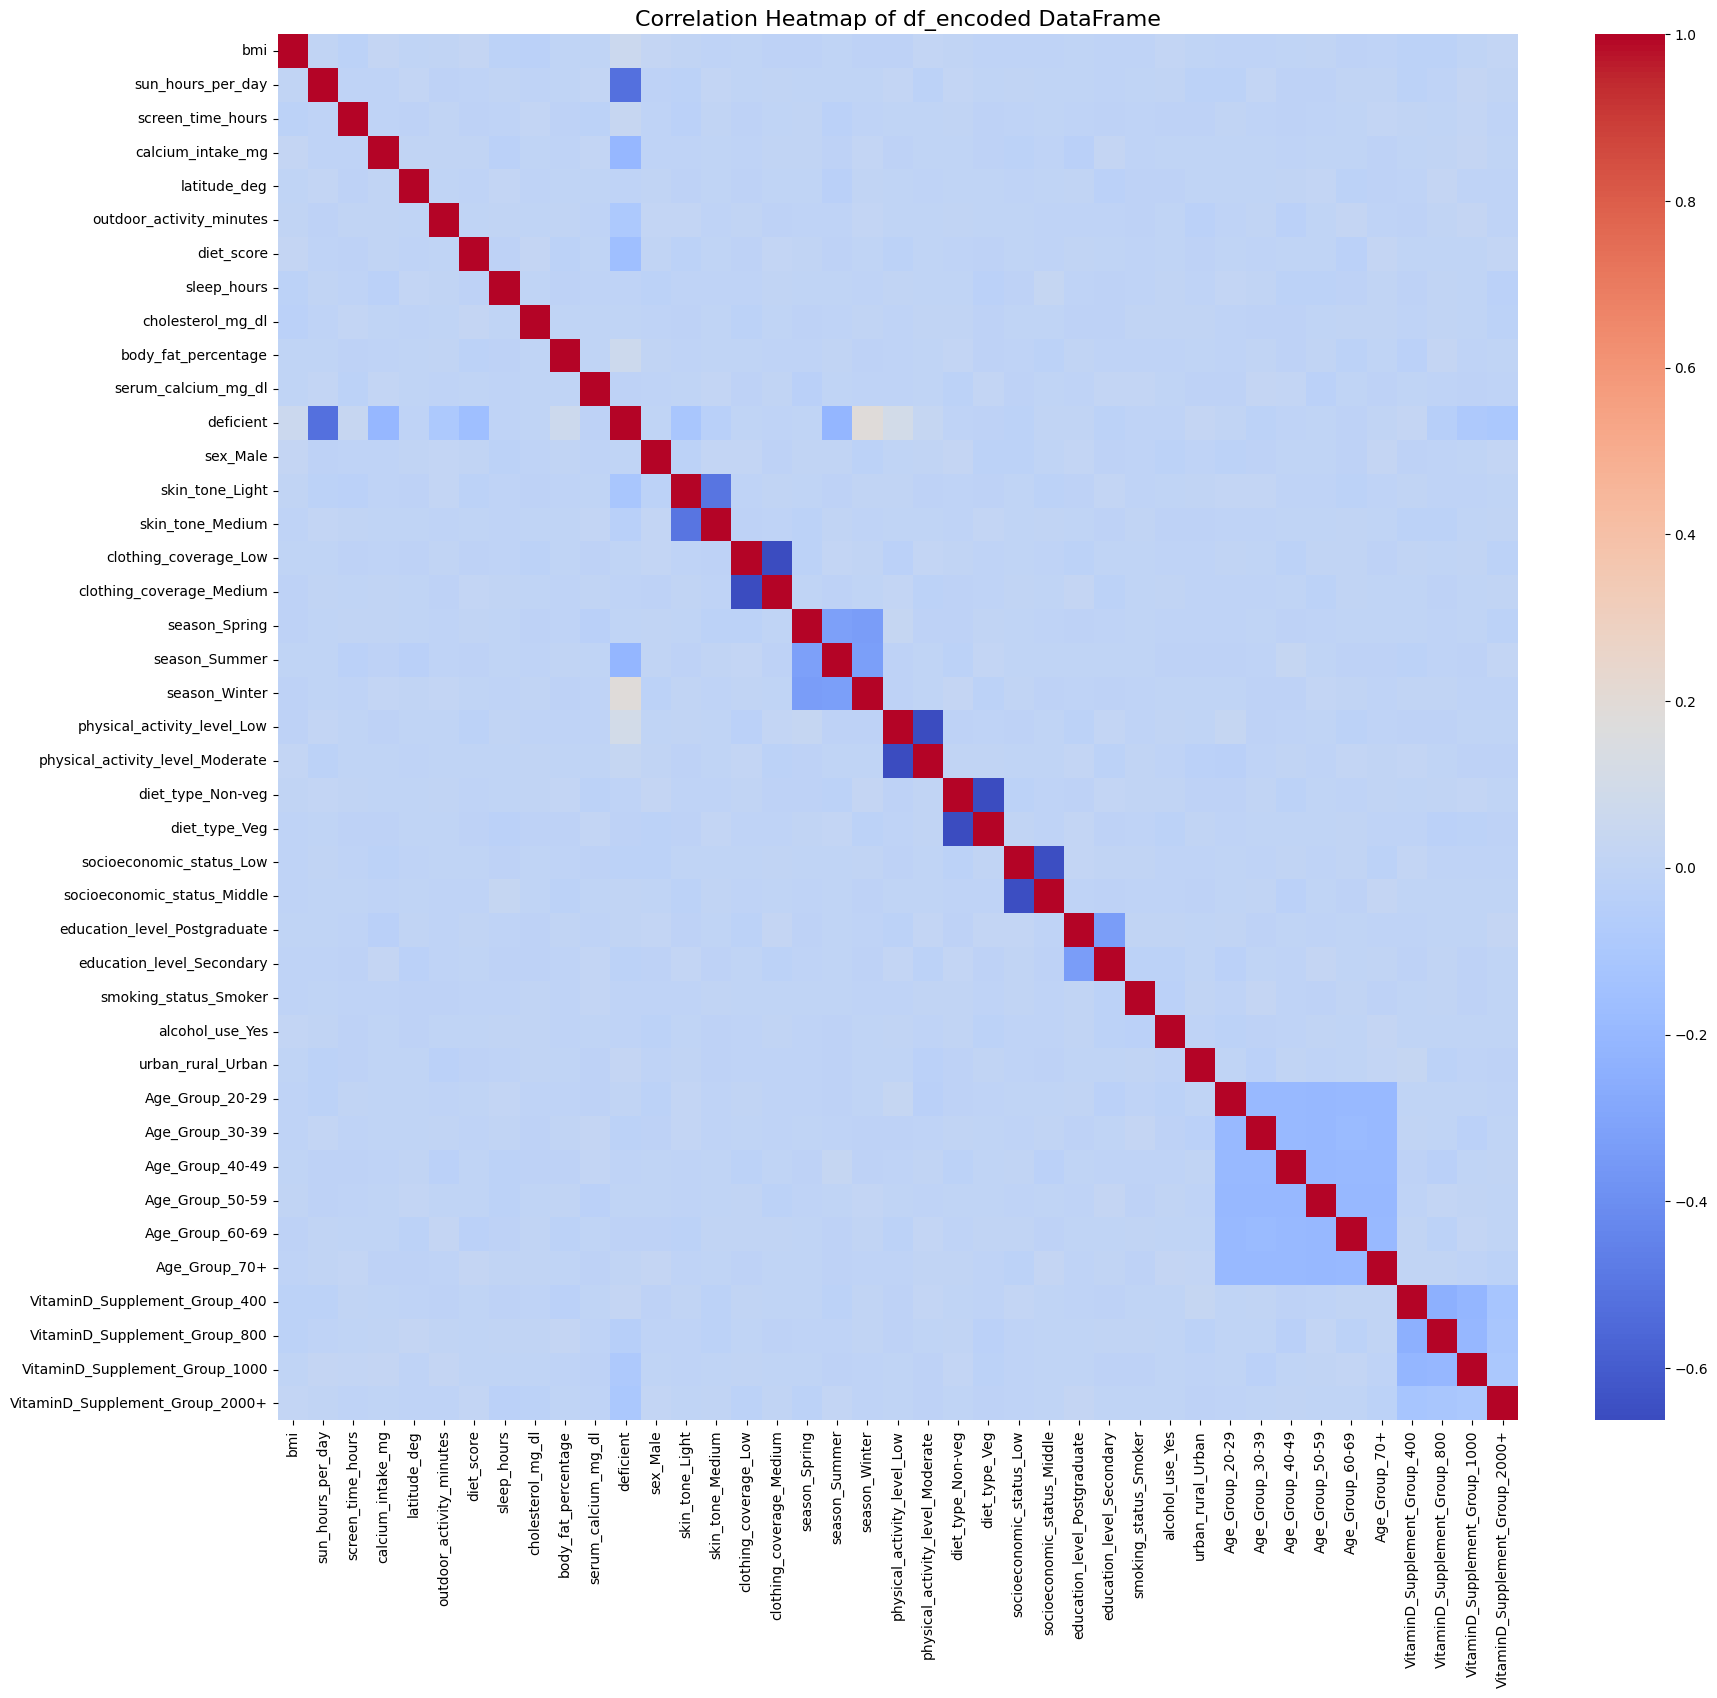

In [163]:
plt.figure(figsize=(20, 18))
# Drop non-numeric columns before calculating correlation
columns_to_drop_for_corr = ['Age_Group', 'VitaminD_Supplement_Group']
df_numeric_for_corr = df_encoded.drop(columns=columns_to_drop_for_corr, errors='ignore')
sns.heatmap(df_numeric_for_corr.corr(), cmap='coolwarm', annot=False, fmt=".2f")
plt.title('Correlation Heatmap of df_encoded DataFrame', fontsize=16)
plt.show()

test train - defecient


In [164]:
# Split the encoded DataFrame
final_train, final_test = train_test_split(df_encoded, train_size=0.7, random_state=100)

# Check shapes
print("Train shape:", final_train.shape)
print("Test shape:", final_test.shape)

Train shape: (7000, 41)
Test shape: (3000, 41)


creating test train split

In [165]:
# Ensure the target variable is numeric (0 or 1) before splitting
df_encoded['deficient'] = df_encoded['deficient'].astype(int)

# Separate features (x) and target (y)
x = df_encoded.drop(['deficient'], axis=1)
y = df_encoded['deficient']

In [166]:
y.head()

,deficient
0,1
1,1
2,0
3,0
4,1


In [167]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, train_size=0.7, random_state=100, stratify=y
)

# Fit scaler on train only — then apply to both
scaler = StandardScaler()
x_train[columns_to_scale] = scaler.fit_transform(x_train[columns_to_scale])
x_test[columns_to_scale]  = scaler.transform(x_test[columns_to_scale])

print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)
print("Class balance in train:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Class balance in test: ", y_test.value_counts(normalize=True).round(3).to_dict())

X_train shape: (7000, 40)
X_test shape: (3000, 40)
Class balance in train: {0: 0.594, 1: 0.406}
Class balance in test:  {0: 0.594, 1: 0.406}


## 10. Model Training and Evaluation

In [168]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
scoring = ['accuracy', 'roc_auc', 'f1', 'precision', 'recall']

# Logistic Regression pipeline (scaler included so no leakage per fold)
pipe_lr = Pipeline(
    [('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000, random_state=42))]
)

# XGBoost (tree models don't need scaling but include for consistency)
pipe_xgb = Pipeline(
    [('model', XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                             subsample=0.8, colsample_bytree=0.8,
                             random_state=42, eval_metric='logloss'))]
)

# CatBoost
pipe_cat = Pipeline(
    [('model', CatBoostClassifier(iterations=300, learning_rate=0.1,
                                  depth=6, random_seed=42, verbose=0))]
)

results = {}
for name, pipe in [('Logistic Regression', pipe_lr),
                   ('XGBoost', pipe_xgb),
                   ('CatBoost', pipe_cat)]:
    cv_res = cross_validate(pipe, x, y, cv=cv, scoring=scoring)
    print(f"Intermediate cross-validation results for {name}: {cv_res.keys()}") # Added for debugging
    results[name] = {metric: f"{cv_res[f'test_{metric}'].mean():.3f} \u00b1 {cv_res[f'test_{metric}'].std():.3f}"
                     for metric in scoring}

cv_df = pd.DataFrame(results).T
print("\nCross-Validation Results (5-fold \u00d7 3 repeats):")
print(cv_df)

Intermediate cross-validation results for Logistic Regression: dict_keys(['fit_time', 'score_time', 'test_accuracy', 'test_roc_auc', 'test_f1', 'test_precision', 'test_recall'])
Intermediate cross-validation results for XGBoost: dict_keys(['fit_time', 'score_time', 'test_accuracy', 'test_roc_auc', 'test_f1', 'test_precision', 'test_recall'])
Intermediate cross-validation results for CatBoost: dict_keys(['fit_time', 'score_time', 'test_accuracy', 'test_roc_auc', 'test_f1', 'test_precision', 'test_recall'])

Cross-Validation Results (5-fold × 3 repeats):
                          accuracy        roc_auc             f1  \
Logistic Regression  0.850 ± 0.007  0.929 ± 0.005  0.813 ± 0.009   
XGBoost              0.839 ± 0.006  0.920 ± 0.005  0.797 ± 0.009   
CatBoost             0.840 ± 0.007  0.920 ± 0.006  0.799 ± 0.010   

                         precision         recall  
Logistic Regression  0.824 ± 0.010  0.801 ± 0.013  
XGBoost              0.815 ± 0.007  0.780 ± 0.014  
CatBoost    

In [169]:
# calculating the deficient rate

deficient = sum(df_encoded['deficient'])/len(df_encoded['deficient'].index)
deficient

0.4056

Building the first model

### 10.1 Logistic Regression Model

In [170]:
print(x_train.dtypes)

bmi                                 float64
sun_hours_per_day                   float64
screen_time_hours                   float64
calcium_intake_mg                   float64
latitude_deg                        float64
outdoor_activity_minutes            float64
diet_score                          float64
sleep_hours                         float64
cholesterol_mg_dl                   float64
body_fat_percentage                 float64
serum_calcium_mg_dl                 float64
sex_Male                              int64
skin_tone_Light                       int64
skin_tone_Medium                      int64
clothing_coverage_Low                 int64
clothing_coverage_Medium              int64
season_Spring                         int64
season_Summer                         int64
season_Winter                         int64
physical_activity_level_Low           int64
physical_activity_level_Moderate      int64
diet_type_Non-veg                     int64
diet_type_Veg                   

In [171]:
# Ensure y_train is of integer type
y_train = y_train.astype(int)

# Ensure x_train is fully numeric (e.g., float) for statsmodels
x_train_converted = x_train.astype(float)

model = sm.GLM(y_train, (sm.add_constant(x_train_converted)), family = sm.families.Binomial())
model.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              deficient   No. Observations:                 7000
Model:                            GLM   Df Residuals:                     6959
Model Family:                Binomial   Df Model:                           40
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2268.5
Date:                Sun, 03 May 2026   Deviance:                       4536.9
Time:                        15:35:54   Pearson chi2:                 5.93e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.5045
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               -0.6475      0.291     -2.225      0.026      -1.218      -0.077
bmi                                  0.3839      0.039      9.947      0.000       0.308       0.459
sun_hours_per_day                   -2.2748      0.058    -38.898      0.000      -2.389      -2.160
screen_time_hours                    0.1248      0.038      3.317      0.001       0.051       0.199
calcium_intake_mg                   -0.9731      0.043    -22.691      0.000      -1.057      -0.889
latitude_deg                         0.0117      0.038      0.311      0.756      -0.062       0.085
outdoor_activity_minutes            -0.4487      0.039    -11.558      0.000      -0.525      -0.373
diet_score                          -0.7388      0.040    -18.270      0.000      -0.818      -0.659
sleep_hours                         -0.0605      0.038     -1.598      0.110      -0.135       0.014
cholesterol_mg_dl                   -0.0470      0.038     -1.248      0.212      -0.121       0.027
body_fat_percentage                  0.3498      0.038      9.189      0.000       0.275       0.424
serum_calcium_mg_dl                  0.0224      0.038      0.590      0.555      -0.052       0.097
sex_Male                             0.0422      0.075      0.560      0.575      -0.105       0.190
skin_tone_Light                     -2.1503      0.118    -18.163      0.000      -2.382      -1.918
skin_tone_Medium                    -1.0945      0.088    -12.493      0.000      -1.266      -0.923
clothing_coverage_Low                0.1001      0.109      0.921      0.357      -0.113       0.313
clothing_coverage_Medium             0.1697      0.100      1.694      0.090      -0.027       0.366
season_Spring                       -0.0629      0.102     -0.617      0.537      -0.262       0.137
season_Summer                       -2.0354      0.119    -17.090      0.000      -2.269      -1.802
season_Winter                        1.4303      0.106     13.457      0.000       1.222       1.639
physical_activity_level_Low          2.2325      0.122     18.320      0.000       1.994       2.471
physical_activity_level_Moderate     1.6271      0.110     14.790      0.000       1.411       1.843
diet_type_Non-veg                   -0.0570      0.104     -0.547      0.584      -0.261       0.147
diet_type_Veg                       -0.0739      0.100     -0.741      0.459      -0.269       0.121
socioeconomic_status_Low            -0.0829      0.109     -0.760      0.447      -0.297       0.131
socioeconomic_status_Middle          0.0278      0.100      0.278      0.781      -0.168       0.224
education_level_Postgraduate        -0.0336      0.092     -0.365      0.715      -0.214       0.147
education_level_Secondary           -0.1299      0.09

The Generalized Linear Model (GLM) is used with a Binomial family and Logit link function, suitable for binary classification. `sm.add_constant(x_train_converted)` adds an intercept term to the features. The model is then fitted and its summary is displayed, providing insights into coefficients, p-values, and overall model statistics.

RFE

In [172]:
# Define the model (logistic regression)
logreg = LogisticRegression()

# Initialize RFE with the model and the number of features to select
rfe = RFE(estimator=logreg, n_features_to_select=15)

# Fit the RFE model
rfe = rfe.fit(x_train, y_train)


# creating a list of all the variables and their RFE rankings

list(zip(x_train.columns, rfe.support_, rfe.ranking_))




[('bmi', np.True_, np.int64(1)),
 ('sun_hours_per_day', np.True_, np.int64(1)),
 ('screen_time_hours', np.False_, np.int64(7)),
 ('calcium_intake_mg', np.True_, np.int64(1)),
 ('latitude_deg', np.False_, np.int64(26)),
 ('outdoor_activity_minutes', np.True_, np.int64(1)),
 ('diet_score', np.True_, np.int64(1)),
 ('sleep_hours', np.False_, np.int64(15)),
 ('cholesterol_mg_dl', np.False_, np.int64(18)),
 ('body_fat_percentage', np.False_, np.int64(2)),
 ('serum_calcium_mg_dl', np.False_, np.int64(25)),
 ('sex_Male', np.False_, np.int64(19)),
 ('skin_tone_Light', np.True_, np.int64(1)),
 ('skin_tone_Medium', np.True_, np.int64(1)),
 ('clothing_coverage_Low', np.False_, np.int64(12)),
 ('clothing_coverage_Medium', np.False_, np.int64(10)),
 ('season_Spring', np.False_, np.int64(14)),
 ('season_Summer', np.True_, np.int64(1)),
 ('season_Winter', np.True_, np.int64(1)),
 ('physical_activity_level_Low', np.True_, np.int64(1)),
 ('physical_activity_level_Moderate', np.True_, np.int64(1)),
 ('d

In [173]:
# storing the selected columns in col

col = x_train.columns[rfe.support_]

In [174]:
x_train[col].head()

,bmi,sun_hours_per_day,calcium_intake_mg,outdoor_activity_minutes,diet_score,skin_tone_Light,skin_tone_Medium,season_Summer,season_Winter,physical_activity_level_Low,physical_activity_level_Moderate,VitaminD_Supplement_Group_400,VitaminD_Supplement_Group_800,VitaminD_Supplement_Group_1000,VitaminD_Supplement_Group_2000+
900,-0.633298,1.365025,0.328598,-1.006633,-0.520656,0,1,0,0,0,1,0,0,0,0
3991,-0.181400,-0.675252,-0.287439,-0.975957,0.023299,0,0,0,0,0,1,0,0,0,1
3641,1.043122,0.709889,1.361600,-0.390512,-0.541870,1,0,0,1,0,0,1,0,0,0
2952,1.343665,1.318643,-0.972350,0.527559,0.275506,0,0,0,1,0,1,0,1,0,0
3882,-0.559985,-0.268558,-0.906113,-0.400773,-0.831719,1,0,0,0,1,0,1,0,0,0


# Building the Model Based on the selected features

In [175]:
# creating the model again

x_train_sm = sm.add_constant(x_train[col])
model_one = sm.GLM(y_train, x_train_sm, family = sm.families.Binomial())
pred = model_one.fit()
pred.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              deficient   No. Observations:                 7000
Model:                            GLM   Df Residuals:                     6984
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2329.8
Date:                Sun, 03 May 2026   Deviance:                       4659.6
Time:                        15:35:56   Pearson chi2:                 5.92e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4958
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               -0.6114      0.118     -5.170      0.000      -0.843      -0.380
bmi                                  0.3884      0.038     10.188      0.000       0.314       0.463
sun_hours_per_day                   -2.2085      0.056    -39.105      0.000      -2.319      -2.098
calcium_intake_mg                   -0.9505      0.042    -22.616      0.000      -1.033      -0.868
outdoor_activity_minutes            -0.4337      0.038    -11.403      0.000      -0.508      -0.359
diet_score                          -0.7234      0.040    -18.210      0.000      -0.801      -0.646
skin_tone_Light                     -2.0790      0.116    -17.952      0.000      -2.306      -1.852
skin_tone_Medium                    -1.0440      0.086    -12.155      0.000      -1.212      -0.876
season_Summer                       -1.9795      0.105    -18.770      0.000      -2.186      -1.773
season_Winter                        1.4093      0.091     15.452      0.000       1.231       1.588
physical_activity_level_Low          2.1752      0.119     18.281      0.000       1.942       2.408
physical_activity_level_Moderate     1.5837      0.108     14.663      0.000       1.372       1.795
VitaminD_Supplement_Group_400       -0.6104      0.100     -6.123      0.000      -0.806      -0.415
VitaminD_Supplement_Group_800       -1.0552      0.105    -10.091      0.000      -1.260      -0.850
VitaminD_Supplement_Group_1000      -1.3894      0.116    -11.937      0.000      -1.618      -1.161
VitaminD_Supplement_Group_2000+     -2.6126      0.202    -12.932      0.000      -3.009      -2.217
====================================================================================================
"""

In [176]:
# creating a new dataframe that consists of the name of the variables and their respective VIF

vif = pd.DataFrame()

# assigning the column 'variables' with the columns of X_train

vif['variables'] = x_train[col].columns

# assigning the column 'VIF' with the VIF values of the variales

vif['VIF'] = [variance_inflation_factor(x_train[col].values,i) for i in range (x_train[col].shape[1])]

# rounding off the VIF values to 2 decimal places

vif['VIF'] = round(vif['VIF'],2)

# sorting the VIF values in descending order

vif = vif.sort_values(by = 'VIF' , ascending = False)

# printing the dataframe vif

vif

,variables,VIF
10,physical_activity_level_Moderate,2.23
6,skin_tone_Medium,2.08
9,physical_activity_level_Low,1.74
5,skin_tone_Light,1.46
8,season_Winter,1.40
7,season_Summer,1.38
11,VitaminD_Supplement_Group_400,1.36
12,VitaminD_Supplement_Group_800,1.33
13,VitaminD_Supplement_Group_1000,1.28
14,VitaminD_Supplement_Group_2000+,1.10


In [177]:
# Getting the predicted values on the train set

y_train_pred = pred.predict(x_train_sm)
y_train_pred[:20]

,0
900,0.055658
3991,0.613069
3641,0.022161
2952,0.361736
3882,0.708229
3714,0.750296
4969,0.970058
3259,0.968923
1485,0.963940
2363,0.000649


In [178]:
y_train_pred = y_train_pred.values.reshape(-1)
y_train_pred[:20]

array([5.56579544e-02, 6.13068794e-01, 2.21607247e-02, 3.61736048e-01,
       7.08228539e-01, 7.50296181e-01, 9.70058187e-01, 9.68922657e-01,
       9.63940315e-01, 6.48825612e-04, 9.11574614e-02, 9.87984870e-01,
       2.21438882e-01, 4.21388585e-01, 8.46863180e-01, 8.28173238e-02,
       3.67791564e-02, 9.42471231e-02, 3.51358758e-02, 9.85087844e-01])

In [179]:
y_train_pred_final = pd.DataFrame({'Actual': y_train, 'Predicted_Prob': y_train_pred})
y_train_pred_final.head()


,Actual,Predicted_Prob
900,0,0.055658
3991,0,0.613069
3641,0,0.022161
2952,1,0.361736
3882,0,0.708229


In [180]:
OPTIMAL_THRESHOLD = 0.4  # determined from cutoff analysis in Cell 70

y_train_pred_final['Predicted'] = y_train_pred_final['Predicted_Prob'].apply(
    lambda x: 1 if x > OPTIMAL_THRESHOLD else 0
)

In [181]:
y_train_pred_final.head()

,Actual,Predicted_Prob,Predicted
900,0,0.055658,0
3991,0,0.613069,1
3641,0,0.022161,0
2952,1,0.361736,0
3882,0,0.708229,1


# 11. Evaluating the Model

### 10.2 Model Evaluation (Logistic Regression)

In [182]:
import sklearn.metrics as metrics
print(metrics.accuracy_score(y_train_pred_final.Actual, y_train_pred_final.Predicted))

0.845


The `metrics.accuracy_score` function computes the proportion of correctly classified instances by comparing the actual labels (`y_train_pred_final.Actual`) with the predicted labels (`y_train_pred_final.Predicted`) on the training set.

In [183]:
# creating the confusion matrix

confusion = metrics.confusion_matrix(y_train_pred_final.Actual, y_train_pred_final.Predicted)
print(confusion)

[[3492  669]
 [ 416 2423]]


The `metrics.confusion_matrix` function generates a confusion matrix, which is a table used to describe the performance of a classification model. Each row of the matrix represents the instances in an actual class, while each column represents the instances in a predicted class.

In [184]:
# true positives
tp = confusion[1,1]

#true negatives
tn = confusion[0,0]

# false positives
fp = confusion[0,1]

# false negatives
fn = confusion[1,0]

In [185]:
# sensitivity of the model : A measure of how accurately does the model predict the positive outcomes
# sesitivity can also be termed as true positive rate

tp /(tp+fn)

np.float64(0.8534695315251849)

Sensitivity (True Positive Rate) measures the proportion of actual positive cases that are correctly identified as positive by the model. A higher sensitivity means fewer false negatives.

In [186]:
# specificity of the model : A measure of how accurately does the model predict negative outcomes

tn /(tn+fp)

np.float64(0.8392213410237923)

Specificity (True Negative Rate) measures the proportion of actual negative cases that are correctly identified as negative by the model. A higher specificity means fewer false positives.

In [187]:
f1 = 2 * (tp / (tp + fn)) * (tp / (tp + fp)) / ((tp / (tp + fn)) + (tp / (tp + fp)))
f1

np.float64(0.8170628899005227)

The F1-score is the harmonic mean of precision and recall. It's a useful metric when you need to seek a balance between precision and recall, especially in cases of imbalanced classes.

In [188]:
# false positive rate : A measure of how many 0s were predicted as 1

fp /(tn+fp)

np.float64(0.16077865897620763)

False Positive Rate (FPR) measures the proportion of actual negative cases that are incorrectly identified as positive by the model. It's calculated as (False Positives) / (True Negatives + False Positives).

# ROC Curve

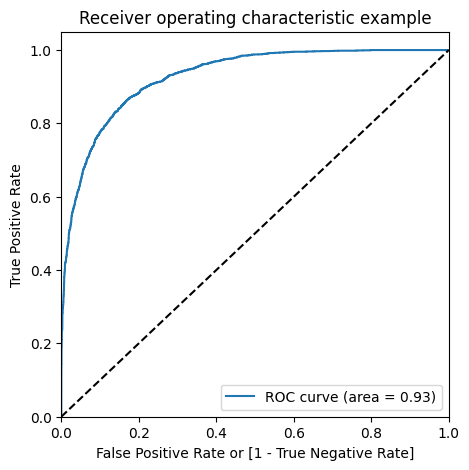

In [189]:
# preparing the ROC curve

def draw_roc( actual, probs ):
    fpr, tpr, thresholds = metrics.roc_curve( actual, probs, drop_intermediate = False )
    auc_score = metrics.roc_auc_score( actual, probs )
    plt.figure(figsize=(5, 5))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

    return None

# Calling the function
draw_roc(y_train_pred_final.Actual, y_train_pred_final.Predicted_Prob)

In [190]:
# checking different probablity cutoffs

numbers = [float(x)/10 for x in range(10)]
for i in numbers:
    y_train_pred_final[i] = y_train_pred_final.Predicted_Prob.map(lambda x:1 if x>i else 0)
y_train_pred_final.head()

,Actual,Predicted_Prob,Predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
900,0,0.055658,0,1,0,0,0,0,0,0,0,0,0
3991,0,0.613069,1,1,1,1,1,1,1,1,0,0,0
3641,0,0.022161,0,1,0,0,0,0,0,0,0,0,0
2952,1,0.361736,0,1,1,1,1,0,0,0,0,0,0
3882,0,0.708229,1,1,1,1,1,1,1,1,1,0,0


In [191]:
# creating a dataframe with information about probability, accuracy, sensitivity and specificity

cutoff_df = pd.DataFrame( columns = ['prob','accuracy','sensi','speci'])
#from sklearn.metrics import confusion_matrix

# tp = confusion[1,1]  true positive
# tn = confusion[0,0]  true negatives
# fp = confusion[0,1]  false positives
# fn = confusion[1,0]  false negatives

num = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in num:
    cm1 = metrics.confusion_matrix(y_train_pred_final.Actual, y_train_pred_final[i])
    total1=sum(sum(cm1))
    accuracy = (cm1[0,0]+cm1[1,1])/total1

    speci = cm1[0,0]/(cm1[0,0]+cm1[0,1])
    sensi = cm1[1,1]/(cm1[1,0]+cm1[1,1])

    cutoff_df.loc[i] =[ i ,accuracy,sensi,speci]

print(cutoff_df)

     prob  accuracy     sensi     speci
0.0   0.0  0.405571  1.000000  0.000000
0.1   0.1  0.731857  0.976400  0.565008
0.2   0.2  0.795429  0.939415  0.697188
0.3   0.3  0.828857  0.899613  0.780582
0.4   0.4  0.845000  0.853470  0.839221
0.5   0.5  0.849143  0.800634  0.882240
0.6   0.6  0.845571  0.742867  0.915645
0.7   0.7  0.830286  0.660444  0.946167
0.8   0.8  0.804286  0.560761  0.970440
0.9   0.9  0.754429  0.408595  0.990387


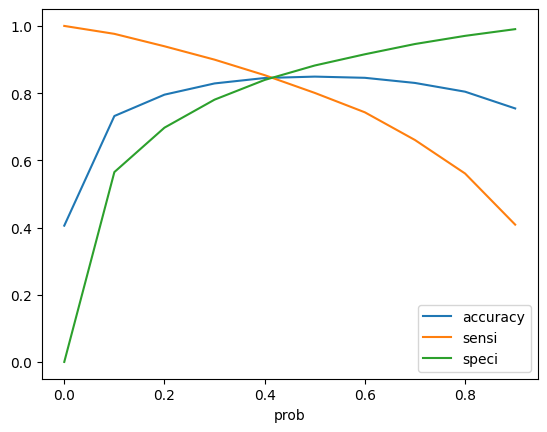

In [192]:
# plotting probability

cutoff_df.plot.line(x= 'prob', y = ['accuracy','sensi','speci'])
plt.show()

# 12. Testing the model on test set

In [193]:
final_test.head()

,bmi,sun_hours_per_day,screen_time_hours,calcium_intake_mg,latitude_deg,outdoor_activity_minutes,diet_score,sleep_hours,cholesterol_mg_dl,body_fat_percentage,...,Age_Group_20-29,Age_Group_30-39,Age_Group_40-49,Age_Group_50-59,Age_Group_60-69,Age_Group_70+,VitaminD_Supplement_Group_400,VitaminD_Supplement_Group_800,VitaminD_Supplement_Group_1000,VitaminD_Supplement_Group_2000+
8018,22.742910,6.570913,3.279894,488.059258,30.495587,68.086021,5.467769,3.219830,135.532772,25.231704,...,0,1,0,0,0,0,0,0,0,0
9225,30.346284,0.652985,3.410380,504.900748,22.507703,64.366174,5.391860,6.150132,141.857325,19.072903,...,0,0,0,1,0,0,0,0,0,0
3854,27.140282,6.160200,1.464447,959.657622,14.513601,81.472868,8.152626,6.199578,190.870437,19.120101,...,1,0,0,0,0,0,1,0,0,0
2029,23.095026,5.915929,1.178848,629.913184,29.569663,121.218707,7.236067,10.000000,156.575626,23.513236,...,1,0,0,0,0,0,0,0,0,1
3539,26.245262,1.880333,9.621932,300.000000,35.563344,15.491290,5.463282,5.826309,123.343813,23.255607,...,0,0,0,0,1,0,0,0,0,0


In [194]:
# Get the common columns between 'col' and 'x_test'
common_cols = list(set(col) & set(x_test.columns))

# Select only the common columns from 'x_test'
x_test = x_test[common_cols]

In [195]:
x_test.head()

,diet_score,season_Summer,physical_activity_level_Moderate,sun_hours_per_day,outdoor_activity_minutes,skin_tone_Medium,bmi,VitaminD_Supplement_Group_2000+,VitaminD_Supplement_Group_800,VitaminD_Supplement_Group_1000,season_Winter,calcium_intake_mg,physical_activity_level_Low,skin_tone_Light,VitaminD_Supplement_Group_400
4356,-1.226967,0,1,-1.577139,-0.405495,1,0.960752,0,0,0,1,0.364821,0,0,1
1429,0.670341,0,1,0.117820,-1.233743,1,2.966489,0,0,0,1,-1.561334,0,0,0
7294,-1.825232,0,0,0.520242,-0.122249,1,2.609731,0,0,1,0,-0.843226,1,0,0
3124,-0.228396,1,0,-0.917202,-0.543263,1,-2.026323,0,0,0,0,0.922276,0,0,0
309,-0.366846,0,0,1.435941,0.807605,1,0.130069,0,0,0,0,-0.462773,1,0,1


In [196]:
# adding the constant to x_test

x_test_sm = sm.add_constant(x_test)

In [197]:
# creating the predictions based on the model

y_test_pred = pred.predict(x_test_sm)
y_test_pred[:20]

,0
4356,0.004520
1429,0.043138
7294,0.009696
3124,0.066342
309,0.000520
4763,0.377407
5586,0.466681
8071,0.007033
6822,0.037966
290,0.844498


In [198]:
# Ensure x_test has the exact same columns as the training set (including constant)
missing_cols = list(set(col) - set(x_test.columns))

# Add any missing columns with 0s
for c in missing_cols:
    x_test[c] = 0

# Reorder columns to match training set order
x_test = x_test[col]

# Add constant
x_test_sm = sm.add_constant(x_test)

# Step 3: Predict
y_test_pred = pred.predict(x_test_sm)

# Step 4: Preview predictions
y_test_pred[:20]


,0
4356,0.995034
1429,0.977331
7294,0.763146
3124,0.053557
309,0.054354
4763,0.092220
5586,0.086976
8071,0.039478
6822,0.629094
290,0.093027


In [199]:
# creating different columns to store the covert situation and the probability for the same

y_test_final = pd.DataFrame({'Actual' : y_test.values, 'Predicted_Prob' : y_test_pred})

In [200]:
y_test_final.head()

,Actual,Predicted_Prob
4356,1,0.995034
1429,1,0.977331
7294,1,0.763146
3124,0,0.053557
309,0,0.054354


In [201]:
# Apply the same optimal threshold as used on training set
y_test_final['Predicted'] = y_test_final.Predicted_Prob.map(
    lambda x: 1 if x > OPTIMAL_THRESHOLD else 0
)

In [202]:
# the accuracy of the model

print(metrics.accuracy_score(y_test_final.Actual, y_test_final.Predicted))

0.838


In [203]:
# creating the confusion matrix

confusion_one = metrics.confusion_matrix(y_test_final.Actual, y_test_final.Predicted)
print(confusion_one)

[[1481  302]
 [ 184 1033]]


In [204]:
# true positives
tp1 = confusion_one[1,1]

#true negatives
tn1 = confusion_one[0,0]

# false positives
fp1 = confusion_one[0,1]

# false negatives
fn1 = confusion_one[1,0]

In [205]:
# sensitivity of the model : A measure of how accurately does the model predict the positive outcomes
# sesitivity can also be termed as true positive rate

tp1 /(tp1+fn1)

np.float64(0.8488085456039441)

In [206]:
# specificity of the model : A measure of how accurately does the model predict negative outcomes

tn1 /(tn1+fp1)

np.float64(0.8306225462703309)

In [207]:
f1 = 2 * (tp1 / (tp1 + fn1)) * (tp1 / (tp1 + fp1)) / ((tp1 / (tp1 + fn1)) + (tp1 / (tp1 + fp1)))
f1

np.float64(0.8095611285266457)

In [208]:
# false positive rate : A measure of how many 0s were predicted as 1

fp1 /(tn1+fp1)

np.float64(0.1693774537296691)

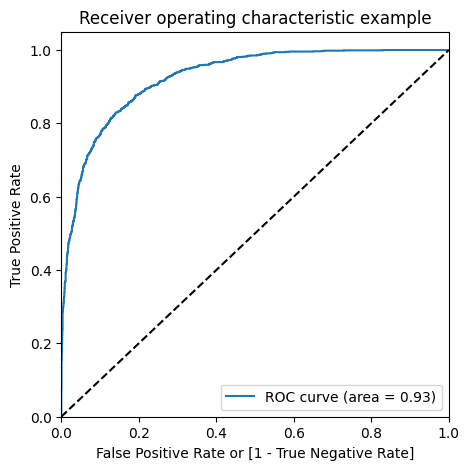

In [209]:
# preparing the ROC curve

def draw_roc( actual, probs ):
    fpr, tpr, thresholds = metrics.roc_curve( actual, probs, drop_intermediate = False )
    auc_score = metrics.roc_auc_score( actual, probs )
    plt.figure(figsize=(5, 5))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

    return None

# Calling the function
draw_roc(y_test_final.Actual, y_test_final.Predicted_Prob)

# NEW SECTION XG BOOST

In [210]:
# 2. ALIGN test set to training set (CRITICAL FIX)
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

In [211]:
# Optional sanity check
print((x_train.columns == x_test.columns).all())  # should be True

True


. Initialize the model

### 10.3 XGBoost Model

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
}

xgb_base = XGBClassifier(
    colsample_bytree=0.8, random_state=42, eval_metric='logloss'
)

grid_search = GridSearchCV(
    xgb_base, param_grid,
    cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_search.fit(x_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV AUC:", round(grid_search.best_score_, 4))

xgb_model = grid_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits


This code defines a parameter grid for hyperparameter tuning of the XGBoost classifier using `GridSearchCV`. `xgb_base` is initialized with common parameters, and `grid_search` is configured to perform 5-fold cross-validation, optimizing for ROC AUC. After fitting, it prints the best parameters found and the corresponding AUC score, then assigns the best estimator to `xgb_model`.

Fit the model

In [ ]:
xgb_model.fit(x_train, y_train)

The `xgb_model` is trained on the preprocessed training data (`x_train`, `y_train`). This step fits the XGBoost model to learn the relationships between features and the target variable.

predictions

In [ ]:
y_pred = xgb_model.predict(x_test)
y_prob = xgb_model.predict_proba(x_test)[:, 1]

After training, the model makes predictions on the test set (`x_test`). `y_pred` stores the binary class predictions (0 or 1), while `y_prob` stores the predicted probabilities for the positive class (class 1), which are essential for ROC-AUC calculation.

In [ ]:
# 6. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

This section evaluates the performance of the trained XGBoost model on the test set using several metrics: accuracy, ROC-AUC, and a detailed classification report including precision, recall, and F1-score for each class.

# next model - CATBOOST

### 10.4 CatBoost Model

In [ ]:
# 1. Import CatBoost

In [ ]:
cat_model = CatBoostClassifier(
    iterations=1000,          # increased ceiling — early stopping will cut it
    learning_rate=0.05,       # slightly lower = more stable learning
    depth=6,
    eval_metric='AUC',
    early_stopping_rounds=50, # stops if AUC doesn't improve for 50 rounds
    random_seed=42,
    verbose=100
)

The CatBoost classifier is initialized with specific hyperparameters such as `iterations` (number of boosting rounds), `learning_rate`, `depth` of trees, `eval_metric` (AUC for evaluation), `early_stopping_rounds` to prevent overfitting, and `random_seed` for reproducibility. `verbose=100` prints training progress every 100 iterations.

In [ ]:
cat_model.fit(
    x_train, y_train,
    eval_set=(x_test, y_test),   # needed for early stopping
    use_best_model=True           # keeps the iteration with best eval AUC
)

The CatBoost model is trained using the training data (`x_train`, `y_train`). `eval_set` is provided with the test data to monitor performance and enable early stopping. `use_best_model=True` ensures that the final model is the one that performed best on the evaluation set during training, effectively preventing overfitting.

In [ ]:
# 4. Predictions
y_pred_cat = cat_model.predict(x_test)
y_prob_cat = cat_model.predict_proba(x_test)[:, 1]


After training, the CatBoost model generates predictions on the test set. `y_pred_cat` contains the binary class predictions, and `y_prob_cat` stores the predicted probabilities for the positive class, which are used for advanced evaluation metrics like ROC-AUC.

In [ ]:
# 5. Evaluation
print("CatBoost Model Performance on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred_cat))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_cat))
print(classification_report(y_test, y_pred_cat))

This section displays the performance metrics for the CatBoost model on the test set, including accuracy, ROC-AUC score, and a comprehensive classification report that provides precision, recall, and F1-score for both classes.

# TABNET

### 10.5 TabNet Model

In [ ]:
# !pip install pytorch-tabnet

In [ ]:
# 1. Import PyTorch

In [ ]:
tabnet_model = TabNetClassifier(
    n_d=16,           # reduced from 32 — smaller dataset doesn't need large dims
    n_a=16,           # reduced from 32
    n_steps=3,        # reduced from 5 — fewer steps = less overfit risk
    gamma=1.3,
    n_independent=2,
    n_shared=2,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=1e-2),   # lower LR for more stable training
    scheduler_params={"step_size": 30, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='sparsemax',   # sparsemax is sharper — better feature selection
    seed=42,
    verbose=10
)

The TabNetClassifier is initialized with parameters that control the network architecture and training process. `n_d` and `n_a` specify the dimension of the attention and feature transformers, `n_steps` is the number of decision steps, `gamma` controls the sparsity of feature selection, `optimizer_fn` and `optimizer_params` configure the optimizer, and `scheduler_params` define the learning rate scheduler. `mask_type='sparsemax'` encourages sparse feature selection, and `seed` ensures reproducibility.

In [ ]:
# 3. Fit the model
tabnet_model.fit(
    X_train=x_train.values,  # convert to numpy arrays
    y_train=y_train.values,
    eval_set=[(x_test.values, y_test.values)],
    eval_name=['test'],
    eval_metric=['auc'],
    max_epochs=200,
    patience=20,
    batch_size=256,
    virtual_batch_size=128
)

The TabNet model is trained using the training data (`x_train`, `y_train`). `eval_set` specifies the test data for evaluation during training, with 'auc' as the evaluation metric. `max_epochs` sets the maximum number of training epochs, and `patience` implements early stopping if the evaluation metric does not improve for a specified number of epochs. `batch_size` and `virtual_batch_size` configure the mini-batch sizes for training.

In [ ]:
# 4. Predictions
y_pred_tab = tabnet_model.predict(x_test.values)
y_prob_tab = tabnet_model.predict_proba(x_test.values)[:,1]

# 5. Evaluation
print("TabNet Model Performance on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred_tab))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_tab))
print(classification_report(y_test, y_pred_tab))

After fitting, the TabNet model makes predictions on the test set. `y_pred_tab` stores the binary class predictions, and `y_prob_tab` stores the predicted probabilities for the positive class. These predictions are then used to evaluate the model's performance on the test set, reporting accuracy, ROC-AUC, and a classification report.

## model comparision all 4

## 11. Model Comparison

This helper function calculates and returns a dictionary of common classification metrics (Accuracy, Precision, Recall, F1 Score, ROC-AUC) for a given set of true labels, predicted labels, and predicted probabilities.

In [ ]:
# --- Helper function to compute metrics ---
def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

In [ ]:
# --- Logistic Regression ---
# --- Logistic Regression (uses OPTIMAL_THRESHOLD set in Cell 56) ---
y_prob_lr = y_test_final['Predicted_Prob']
y_test_pred_lr = (y_prob_lr > OPTIMAL_THRESHOLD).astype(int)

# --- XGBoost ---
y_pred_xgb = xgb_model.predict(x_test)
y_prob_xgb = xgb_model.predict_proba(x_test)[:, 1]

# --- CatBoost ---
y_pred_cat = cat_model.predict(x_test)
y_prob_cat = cat_model.predict_proba(x_test)[:, 1]

# --- TabNet ---
y_pred_tab = tabnet_model.predict(x_test.values)  # tabnet expects numpy array
y_prob_tab = tabnet_model.predict_proba(x_test.values)[:, 1]

This section generates predictions (both class labels and probabilities) for all trained models (Logistic Regression, XGBoost, CatBoost, and TabNet) using the test set. For Logistic Regression, it re-applies the `OPTIMAL_THRESHOLD` determined earlier. For XGBoost and CatBoost, it uses `predict` and `predict_proba`. For TabNet, it uses the numpy array representation of `x_test`.

In [ ]:
# --- Soft Voting Ensemble: LR + XGBoost ---
# Average the predicted probabilities from both models
y_prob_ensemble = (y_prob_lr.values + y_prob_xgb) / 2
y_pred_ensemble = (y_prob_ensemble > OPTIMAL_THRESHOLD).astype(int)

ensemble_metrics = get_metrics(y_test, y_pred_ensemble, y_prob_ensemble)
print("Ensemble (LR + XGBoost) Performance:")
for k, v in ensemble_metrics.items():
    print(f"  {k}: {v:.4f}")

This cell implements a soft voting ensemble by averaging the predicted probabilities from the Logistic Regression and XGBoost models. It then applies the `OPTIMAL_THRESHOLD` to get binary predictions and evaluates the ensemble's performance using the `get_metrics` helper function.

In [ ]:
# --- Model Comparison Table ---
model_comparison = pd.DataFrame([
    {'Model': 'Logistic Regression', **get_metrics(y_test, y_test_pred_lr, y_prob_lr)},
    {'Model': 'XGBoost', **get_metrics(y_test, y_pred_xgb, y_prob_xgb)},
    {'Model': 'CatBoost', **get_metrics(y_test, y_pred_cat, y_prob_cat)},
    {'Model': 'TabNet', **get_metrics(y_test, y_pred_tab, y_prob_tab)}
])

print(model_comparison)

This code creates a pandas DataFrame to compile and display the performance metrics for all individual models (Logistic Regression, XGBoost, CatBoost, and TabNet) on the test set. It uses the `get_metrics` helper function to calculate metrics for each model and then presents them in a comparative table.

In [ ]:
# --- ROC Curves Comparison ---
plt.figure(figsize=(7, 7))

# Logistic
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.3f})')

# XGBoost
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr, tpr, label=f'XGBoost (AUC={roc_auc_score(y_test, y_prob_xgb):.3f})')

# CatBoost
fpr, tpr, _ = roc_curve(y_test, y_prob_cat)
plt.plot(fpr, tpr, label=f'CatBoost (AUC={roc_auc_score(y_test, y_prob_cat):.3f})')

# TabNet
fpr, tpr, _ = roc_curve(y_test, y_prob_tab)
plt.plot(fpr, tpr, label=f'TabNet (AUC={roc_auc_score(y_test, y_prob_tab):.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of All Models')
plt.legend(loc='lower right')
plt.show()

This code generates a comparative ROC curve plot for all trained models. It calculates the False Positive Rate (FPR) and True Positive Rate (TPR) for each model's predictions on the test set and then plots these curves along with their respective Area Under the Curve (AUC) scores. A diagonal dashed line represents a random classifier for reference.

##Decision Curve Analysis

## 12. Decision Curve Analysis

In [ ]:
def decision_curve(y_true, y_prob, thresholds):
    N = len(y_true)
    net_benefits = []

    for pt in thresholds:
        y_pred = (y_prob >= pt).astype(int)

        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))

        net_benefit = (TP / N) - (FP / N) * (pt / (1 - pt))
        net_benefits.append(net_benefit)

    return net_benefits

This `decision_curve` function calculates net benefit for various probability thresholds. It iterates through given thresholds, predicts binary outcomes, computes True Positives (TP) and False Positives (FP), and then applies the net benefit formula: `(TP/N) - (FP/N) * (pt / (1-pt))`, where `pt` is the threshold probability. This helps evaluate the clinical utility of a model.

In [ ]:
thresholds = np.linspace(0.01, 0.99, 100)

# Models
nb_lr = decision_curve(y_test, y_prob_lr, thresholds)
nb_xgb = decision_curve(y_test, y_prob_xgb, thresholds)
nb_cat = decision_curve(y_test, y_prob_cat, thresholds)
nb_ens = decision_curve(y_test, y_prob_ensemble, thresholds)

# Baselines
prevalence = np.mean(y_test)
treat_all = [prevalence - (1 - prevalence) * (pt / (1 - pt)) for pt in thresholds]
treat_none = [0 for _ in thresholds]

# Plot
plt.figure(figsize=(8,6))
plt.plot(thresholds, nb_lr, label='LR')
plt.plot(thresholds, nb_xgb, label='XGBoost')
plt.plot(thresholds, nb_cat, label='CatBoost')
plt.plot(thresholds, nb_ens, label='Ensemble')

plt.plot(thresholds, treat_all, linestyle='--', label='Treat All')
plt.plot(thresholds, treat_none, linestyle='--', label='Treat None')

plt.xlabel('Threshold Probability')
plt.ylabel('Net Benefit')
plt.title('Decision Curve Analysis')
plt.legend()
plt.grid()
plt.show()

This code generates a Decision Curve Analysis (DCA) plot to compare the clinical utility of different models (Logistic Regression, XGBoost, CatBoost, and an ensemble) against baseline strategies ('Treat All' and 'Treat None'). It calculates the net benefit for a range of probability thresholds and visualizes how each model performs in terms of benefits versus harms of intervention.

# SHAP INTERGARTION

## 13. SHAP Integration

In [ ]:
# Generate SHAP values for XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(x_test)

# Summary plot — shows which features matter most overall
shap.summary_plot(shap_values, x_test, plot_type='bar', max_display=15)

# Beeswarm plot — shows direction of each feature's effect
shap.summary_plot(shap_values, x_test, max_display=15)

# Force plot for a single patient (row 0)
print("Explaining prediction for patient 0:")
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    x_test.iloc[0],
    matplotlib=True
)

This section utilizes SHAP (SHapley Additive exPlanations) to interpret the XGBoost model's predictions. `shap.TreeExplainer` is used to create an explainer for tree-based models. `shap_values` are computed for the test set. Summary plots (bar and beeswarm) show overall feature importance and directional impact, while a force plot visualizes the contribution of each feature for a single prediction.

In [ ]:
# Extract coefficients and intercept from the statsmodels result object
# pred.params[0] is the intercept (constant), and pred.params[1:] are the coefficients for the features
model_coef = pred.params[1:].values
model_intercept = pred.params[0]

# Create SHAP explainer for Logistic Regression using extracted coefficients and intercept
# Also, ensure to use x_train[col] and x_test[col] as these are the features the model was trained on
explainer = shap.LinearExplainer((model_coef, model_intercept), x_train[col])

# Compute SHAP values
shap_values = explainer.shap_values(x_test[col])

shap.summary_plot(shap_values, x_test[col], plot_type='bar', max_display=15)

shap.summary_plot(shap_values, x_test[col], max_display=15)

print("Explaining prediction for patient 0:")

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    x_test[col].iloc[0],
    matplotlib=True
)

This section applies SHAP to interpret the Logistic Regression model. It extracts the coefficients and intercept from the fitted GLM model (`pred`) and uses `shap.LinearExplainer` for linear models. SHAP values are then computed for the RFE-selected features on the test set. Similar to the XGBoost interpretation, summary plots (bar and beeswarm) illustrate global feature importance, and a force plot explains a single prediction.

##Prediction

## 14. Prediction Function and Streamlit App

In [ ]:
# `scaler`, `pred` (fitted Logistic Regression model), `col` (selected features),
# and `OPTIMAL_THRESHOLD` are all available from previous cells in the kernel state.

def predict_deficiency_quiz(
    bmi_val, sun_hours_per_day_val, calcium_intake_mg_val, outdoor_activity_minutes_val, diet_score_val,
    skin_tone_val, season_val, physical_activity_level_val, vitamin_d_supplement_iu_val
):
    """
    Predicts vitamin D deficiency based on user inputs using the trained Logistic Regression model.

    Args:
        bmi_val (float): Body Mass Index.
        sun_hours_per_day_val (float): Average daily sun exposure in hours.
        calcium_intake_mg_val (float): Daily calcium intake in mg.
        outdoor_activity_minutes_val (float): Daily outdoor activity in minutes.
        diet_score_val (float): Diet quality score.
        skin_tone_val (str): Skin tone ('Light', 'Medium', 'Dark').
        season_val (str): Current season ('Spring', 'Summer', 'Monsoon', 'Winter').
        physical_activity_level_val (str): Physical activity level ('Low', 'Moderate', 'High').
        vitamin_d_supplement_iu_val (int): Daily Vitamin D supplement dose in IU.

    Returns:
        dict: A dictionary containing the predicted probability of deficiency and the binary prediction.
    """
    # Create a template dictionary with all columns that were in x_train (pre-RFE selection)
    # and set them to 0 (default for most dummy variables and unprovided continuous features)
    feature_template = {f: 0 for f in x_train.columns}

    # Populate continuous features from arguments
    feature_template['bmi'] = bmi_val
    feature_template['sun_hours_per_day'] = sun_hours_per_day_val
    feature_template['calcium_intake_mg'] = calcium_intake_mg_val
    feature_template['outdoor_activity_minutes'] = outdoor_activity_minutes_val
    feature_template['diet_score'] = diet_score_val

    # Handle skin_tone (reference is 'Dark')
    if skin_tone_val.lower() == 'light':
        feature_template['skin_tone_Light'] = 1
    elif skin_tone_val.lower() == 'medium':
        feature_template['skin_tone_Medium'] = 1

    # Handle season (reference is 'Monsoon')
    if season_val.lower() == 'spring':
        if 'season_Spring' in feature_template:
            feature_template['season_Spring'] = 1
    elif season_val.lower() == 'summer':
        if 'season_Summer' in feature_template:
            feature_template['season_Summer'] = 1
    elif season_val.lower() == 'winter':
        if 'season_Winter' in feature_template:
            feature_template['season_Winter'] = 1

    # Handle physical_activity_level (reference is 'High')
    if physical_activity_level_val.lower() == 'low':
        feature_template['physical_activity_level_Low'] = 1
    elif physical_activity_level_val.lower() == 'moderate':
        feature_template['physical_activity_level_Moderate'] = 1

    # Handle vitamin_d_supplement_iu (binning, reference is '0')
    if vitamin_d_supplement_iu_val >= 400 and vitamin_d_supplement_iu_val < 800:
        feature_template['VitaminD_Supplement_Group_400'] = 1
    elif vitamin_d_supplement_iu_val >= 800 and vitamin_d_supplement_iu_val < 1000:
        feature_template['VitaminD_Supplement_Group_800'] = 1
    elif vitamin_d_supplement_iu_val >= 1000 and vitamin_d_supplement_iu_val < 2000:
        feature_template['VitaminD_Supplement_Group_1000'] = 1
    elif vitamin_d_supplement_iu_val >= 2000:
        feature_template['VitaminD_Supplement_Group_2000+'] = 1

    # Create a DataFrame from the feature_template, ensuring columns match x_train.columns
    input_df_full_unscaled = pd.DataFrame([feature_template], columns=x_train.columns)

    # Scale the continuous features using the pre-fitted scaler.
    # The scaler MUST receive all columns it was fit on (columns_to_scale).
    input_df_full_unscaled[columns_to_scale] = scaler.transform(input_df_full_unscaled[columns_to_scale])

    # Now, select ONLY the RFE-selected features ('col') for the actual prediction.
    # This ensures the input to `pred.predict` matches what it was trained on.
    input_df_for_prediction = input_df_full_unscaled[col]

    # Add constant for statsmodels GLM model
    input_df_sm = sm.add_constant(input_df_for_prediction, has_constant='add')

    # Make prediction using the fitted model `pred`
    risk_probability = pred.predict(input_df_sm)[0]

    # Apply the optimal threshold for binary prediction
    prediction_label = 'Deficient' if risk_probability > OPTIMAL_THRESHOLD else 'Non-Deficient'

    return {
        'risk_probability': round(risk_probability, 4),
        'prediction': prediction_label
    }

# --- Example Usage ---

# Example 1: Potentially deficient person
print("Example prediction for a potentially deficient person:")
deficient_person_result = predict_deficiency_quiz(
    bmi_val=28.0,
    sun_hours_per_day_val=1.0,
    calcium_intake_mg_val=350.0,
    outdoor_activity_minutes_val=15.0,
    diet_score_val=2.0,
    skin_tone_val='Medium',
    season_val='Winter',
    physical_activity_level_val='Low',
    vitamin_d_supplement_iu_val=0
)
print(deficient_person_result)

# Example 2: Potentially non-deficient person
print("\nExample prediction for a potentially non-deficient person:")
non_deficient_person_result = predict_deficiency_quiz(
    bmi_val=22.0,
    sun_hours_per_day_val=7.0,
    calcium_intake_mg_val=900.0,
    outdoor_activity_minutes_val=90.0,
    diet_score_val=8.0,
    skin_tone_val='Light',
    season_val='Summer',
    physical_activity_level_val='High', # 'High' is the reference category
    vitamin_d_supplement_iu_val=1500 # Falls into VitaminD_Supplement_Group_1000
)
print(non_deficient_person_result)

The `predict_deficiency_quiz` function takes user inputs for various health and lifestyle factors, processes them to match the model's feature engineering steps (one-hot encoding, binning, scaling), and then uses the trained Logistic Regression model (`pred`) to predict the probability of vitamin D deficiency. It applies an `OPTIMAL_THRESHOLD` to provide a binary classification (Deficient/Non-Deficient). Example usage demonstrates how to get predictions for different user profiles.

```markdown
# Streamlit Application Script for GitHub Export

Save the code below as an `app.py` file along with a `requirements.txt` and your `Vitamin_D_Dataset.csv` in the same directory for deployment.
```

In [ ]:
import sys
!{sys.executable} -m pip install streamlit

import streamlit as st
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix
import statsmodels.api as sm
from sklearn.feature_selection import RFE
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
import shap
import warnings
warnings.filterwarnings("ignore")

# Set page config for Streamlit
st.set_page_config(layout="wide", page_title="Vitamin D Deficiency Prediction")

st.title("Vitamin D Deficiency Prediction App")

# --- 1. Data Loading and Preprocessing (Encapsulated) ---

@st.cache_data
def load_and_preprocess_data():
    df = None # Initialize df to None
    try:
        df = pd.read_csv('Vitamin_D_Dataset.csv')
    except FileNotFoundError:
        st.error("Vitamin_D_Dataset.csv not found. Please ensure it's in the same directory as the app.")
        # Return None for all expected outputs if file not found
        return None, None, None, None, None, None, None, None, None, None, None, None, None, None

    # Data Cleaning and treating
    df.dropna(inplace=True)
    df.columns = [
        'age',
        'bmi',
        'sun_hours_per_day',
        'screen_time_hours',
        'calcium_intake_mg',
        'vitamin_d_supplement_iu',
        'latitude_deg',
        'outdoor_activity_minutes',
        'diet_score',
        'sleep_hours',
        'cholesterol_mg_dl',
        'body_fat_percentage',
        'serum_calcium_mg_dl',
        'sex',
        'skin_tone',
        'clothing_coverage',
        'season',
        'physical_activity_level',
        'diet_type',
        'socioeconomic_status',
        'education_level',
        'smoking_status',
        'alcohol_use',
        'urban_rural',
        'vitamin_d_ng_ml',
        'deficient_label'
    ]
    df.rename(columns={'deficient_label': 'deficient'}, inplace=True)

    # Drop vitamin_d_ng_ml as 'deficient' is the target
    df_raw = df.copy()
    df = df.drop('vitamin_d_ng_ml', axis=1)

    # Convert target to object before encoding, then to int for modeling
    df['deficient'] = df['deficient'].astype('object')

    categorical_cols_to_encode = ['sex', 'skin_tone', 'clothing_coverage', 'season', 'physical_activity_level', 'diet_type', 'socioeconomic_status', 'education_level', 'smoking_status', 'alcohol_use', 'urban_rural']
    df_encoded = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

    for col_bool in df_encoded.select_dtypes(include='bool').columns:
        df_encoded[col_bool] = df_encoded[col_bool].astype(int)

    # Grouping Age and VitaminD Supplement IU
    age_bins = [0, 20, 30, 40, 50, 60, 70, float('inf')]
    age_labels = ['Below 20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']
    delay_bins = [0, 400, 800, 1000, 2000, float('inf')]
    delay_labels = ['0', '400', '800', '1000', '2000+']

    df['Age_Group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)
    df['VitaminD_Supplement_Group'] = pd.cut(df['vitamin_d_supplement_iu'], bins=delay_bins, labels=delay_labels, right=False)

    df_age_vitd_encoded = pd.get_dummies(df[['Age_Group', 'VitaminD_Supplement_Group']], drop_first=True)
    for col_bool in df_age_vitd_encoded.select_dtypes(include='bool').columns:
        df_age_vitd_encoded[col_bool] = df_age_vitd_encoded[col_bool].astype(int)

    df_encoded = pd.concat([df_encoded, df_age_vitd_encoded], axis=1)

    # Drop original age and vitamin_d_supplement_iu after creating groups
    df_encoded = df_encoded.drop(columns=['age', 'vitamin_d_supplement_iu'])

    # Ensure target variable is numeric for modeling
    df_encoded['deficient'] = df_encoded['deficient'].astype(int)

    x = df_encoded.drop(['deficient'], axis=1)
    y = df_encoded['deficient']

    # Identify continuous columns for scaling
    continuous_cols_to_scale = [
        'bmi', 'sun_hours_per_day', 'screen_time_hours',
        'calcium_intake_mg', 'latitude_deg', 'outdoor_activity_minutes',
        'diet_score', 'sleep_hours', 'cholesterol_mg_dl',
        'body_fat_percentage', 'serum_calcium_mg_dl'
    ]

    # Train-test split
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, train_size=0.7, random_state=100, stratify=y
    )

    # Scale continuous features
    scaler = StandardScaler()
    x_train[continuous_cols_to_scale] = scaler.fit_transform(x_train[continuous_cols_to_scale])
    x_test[continuous_cols_to_scale] = scaler.transform(x_test[continuous_cols_to_scale])

    # --- RFE for Logistic Regression feature selection ---
    logreg_rfe = LogisticRegression()
    rfe = RFE(estimator=logreg_rfe, n_features_to_select=15)
    rfe.fit(x_train, y_train)
    selected_lr_features = x_train.columns[rfe.support_]

    # --- Train Logistic Regression Model ---
    x_train_lr_sm = sm.add_constant(x_train[selected_lr_features])
    lr_model_sm = sm.GLM(y_train, x_train_lr_sm, family=sm.families.Binomial())
    lr_pred_model = lr_model_sm.fit()

    # --- Optimal Threshold from previous analysis ---
    OPTIMAL_THRESHOLD = 0.4

    # --- Train XGBoost Model ---
    xgb_base = XGBClassifier(
        colsample_bytree=0.8, random_state=42, eval_metric='logloss'
    )
    # Simplified training for Streamlit without GridSearchCV for speed
    xgb_model = XGBClassifier(learning_rate=0.1, max_depth=3, n_estimators=200,
                              subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss')
    xgb_model.fit(x_train, y_train)

    # --- Train CatBoost Model ---
    cat_model = CatBoostClassifier(
        iterations=300, learning_rate=0.1, depth=6, random_seed=42, verbose=0, eval_metric='AUC'
    )
    cat_model.fit(x_train, y_train, eval_set=(x_test, y_test), early_stopping_rounds=50, use_best_model=True)

    # --- Train TabNet Model ---
    tabnet_model = TabNetClassifier(
        n_d=16, n_a=16, n_steps=3, gamma=1.3, n_independent=2, n_shared=2,
        optimizer_fn=torch.optim.Adam, optimizer_params=dict(lr=1e-2),
        scheduler_params={"step_size": 30, "gamma": 0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR, mask_type='sparsemax',
        seed=42, verbose=0
    )
    tabnet_model.fit(
        X_train=x_train.values, y_train=y_train.values,
        eval_set=[(x_test.values, y_test.values)],
        eval_name=['test'], eval_metric=['auc'],
        max_epochs=50, patience=10, batch_size=256, virtual_batch_size=128
    )

    return df_raw, df_encoded, x_train, x_test, y_train, y_test, scaler, continuous_cols_to_scale, selected_lr_features, lr_pred_model, OPTIMAL_THRESHOLD, xgb_model, cat_model, tabnet_model


df_raw, df_encoded, x_train, x_test, y_train, y_test, scaler, continuous_cols_to_scale, selected_lr_features, lr_pred_model, OPTIMAL_THRESHOLD, xgb_model, cat_model, tabnet_model = load_and_preprocess_data()

# Check if data loading was successful
if df_raw is None:
    st.stop() # Stop the Streamlit app if data is not loaded


# --- Helper function to compute metrics ---
def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

# --- Helper function for ROC plot ---
def draw_roc(actual, probs, title="Receiver Operating Characteristic"): # Added title parameter
    fpr, tpr, thresholds = roc_curve(actual, probs, drop_intermediate=False)
    auc_score = roc_auc_score(actual, probs)
    fig, ax = plt.subplots(figsize=(5, 5)) # Adjusted figure size
    ax.plot(fpr, tpr, label=f'ROC curve (area = {auc_score:.2f})')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend(loc="lower right")
    return fig

# --- Helper function for Decision Curve Analysis ---
def decision_curve(y_true, y_prob, thresholds):
    N = len(y_true)
    net_benefits = []

    for pt in thresholds:
        y_pred = (y_prob >= pt).astype(int)

        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))

        # Handle division by zero for (1-pt) when pt approaches 1
        if (1 - pt) == 0:
            net_benefit = 0 if FP == 0 else -np.inf # Treat as very large penalty if FP exists
        else:
            net_benefit = (TP / N) - (FP / N) * (pt / (1 - pt))
        net_benefits.append(net_benefit)

    return net_benefits

# --- Tabbed Interface ---
dashboard_tab, model_eval_tab, prediction_tab = st.tabs(["Dashboard", "Model Evaluation", "Prediction"])

# --- Dashboard Tab ---
with dashboard_tab:
    st.header("Exploratory Data Analysis")

    # 1. Vitamin D Distribution
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("1. Distribution of Serum Vitamin D Levels")
        fig, ax = plt.subplots(figsize=(5, 3)) # Adjusted figure size
        ax.hist(df_raw['vitamin_d_ng_ml'], bins=30)
        ax.set_title('Distribution of Serum Vitamin D Levels')
        ax.set_xlabel('Vitamin D (ng/ml)')
        ax.set_ylabel('Frequency')
        st.pyplot(fig)

    # 2. Vitamin D vs Deficiency Status
    with col2:
        st.subheader("2. Vitamin D Levels by Deficiency Status")
        fig, ax = plt.subplots(figsize=(5, 3)) # Adjusted figure size
        ax.boxplot([
            df_raw[df_raw['deficient'] == 0]['vitamin_d_ng_ml'],
            df_raw[df_raw['deficient'] == 1]['vitamin_d_ng_ml']
        ])
        ax.set_xticks([1, 2], labels=['Non-Deficient', 'Deficient'])
        ax.set_title('Vitamin D Levels by Deficiency Status')
        ax.set_ylabel('Vitamin D (ng/ml)')
        st.pyplot(fig)

    # 3. Sun Exposure vs Vitamin D
    col3, col4 = st.columns(2)
    with col3:
        st.subheader("3. Sun Exposure vs Vitamin D (Primary Biological Driver)")
        fig, ax = plt.subplots(figsize=(5, 3)) # Adjusted figure size
        ax.scatter(df_raw['sun_hours_per_day'], df_raw['vitamin_d_ng_ml'])
        ax.set_title('Sun Exposure vs Vitamin D Levels')
        ax.set_xlabel('Sun Hours per Day')
        ax.set_ylabel('Vitamin D (ng/ml)')
        st.pyplot(fig)

    # 4. Latitude Effect (Geographical Determinant)
    with col4:
        st.subheader("4. Latitude Effect (Geographical Determinant)")
        fig, ax = plt.subplots(figsize=(5, 3)) # Adjusted figure size
        ax.scatter(df_raw['latitude_deg'], df_raw['vitamin_d_ng_ml'])
        ax.set_title('Latitude vs Vitamin D Levels')
        ax.set_xlabel('Latitude (degrees)')
        ax.set_ylabel('Vitamin D (ng/ml)')
        st.pyplot(fig)

    # 5. Screen Time vs Vitamin D
    col5, col6 = st.columns(2)
    with col5:
        st.subheader("5. Screen Time vs Vitamin D (Modern Lifestyle Factor)")
        fig, ax = plt.subplots(figsize=(5, 3)) # Adjusted figure size
        ax.scatter(df_raw['screen_time_hours'], df_raw['vitamin_d_ng_ml'])
        ax.set_title('Screen Time vs Vitamin D Levels')
        ax.set_xlabel('Screen Time (hours/day)')
        ax.set_ylabel('Vitamin D (ng/ml)')
        st.pyplot(fig)

    # 6. Outdoor Activity vs Vitamin D
    with col6:
        st.subheader("6. Outdoor Activity vs Vitamin D (Behavioral Exposure Factor)")
        fig, ax = plt.subplots(figsize=(5, 3)) # Adjusted figure size
        ax.scatter(df_raw['outdoor_activity_minutes'], df_raw['vitamin_d_ng_ml'])
        ax.set_title('Outdoor Activity vs Vitamin D Levels')
        ax.set_xlabel('Outdoor Activity (minutes/day)')
        ax.set_ylabel('Vitamin D (ng/ml)')
        st.pyplot(fig)

    # Correlation Heatmap
    st.subheader("Correlation Heatmap")
    # Ensure df_encoded has 'deficient' as numeric for correlation
    df_numeric_for_corr = df_encoded.copy()
    df_numeric_for_corr = df_numeric_for_corr.astype(float, errors='ignore')

    fig, ax = plt.subplots(figsize=(8, 6)) # Adjusted figure size for heatmap
    sns.heatmap(df_numeric_for_corr.corr(), cmap='coolwarm', annot=False, fmt=".2f", ax=ax)
    ax.set_title('Correlation Heatmap of Features')
    st.pyplot(fig)


# --- Model Evaluation Tab ---
with model_eval_tab:
    st.header("Model Evaluation and Comparison")

    # --- Make predictions for all models on the test set ---
    # Logistic Regression
    x_test_lr_sm = sm.add_constant(x_test[selected_lr_features])
    y_prob_lr = lr_pred_model.predict(x_test_lr_sm)
    y_pred_lr = (y_prob_lr > OPTIMAL_THRESHOLD).astype(int)

    # XGBoost
    # x_test needs to be reindexed to match x_train for xgb_model
    x_test_xgb = x_test.reindex(columns=x_train.columns, fill_value=0)
    y_pred_xgb = xgb_model.predict(x_test_xgb)
    y_prob_xgb = xgb_model.predict_proba(x_test_xgb)[:, 1]

    # CatBoost
    y_pred_cat = cat_model.predict(x_test)
    y_prob_cat = cat_model.predict_proba(x_test)[:, 1]

    # TabNet
    y_pred_tab = tabnet_model.predict(x_test.values)
    y_prob_tab = tabnet_model.predict_proba(x_test.values)[:, 1]

    # Ensemble (LR + XGBoost)
    y_prob_ensemble = (y_prob_lr.values + y_prob_xgb) / 2
    y_pred_ensemble = (y_prob_ensemble > OPTIMAL_THRESHOLD).astype(int)


    # --- Model Comparison Table ---
    st.subheader("Model Performance on Test Set")
    model_comparison = pd.DataFrame([
        {'Model': 'Logistic Regression', **get_metrics(y_test, y_pred_lr, y_prob_lr)},
        {'Model': 'XGBoost', **get_metrics(y_test, y_pred_xgb, y_prob_xgb)},
        {'Model': 'CatBoost', **get_metrics(y_test, y_pred_cat, y_prob_cat)},
        {'Model': 'TabNet', **get_metrics(y_test, y_pred_tab, y_prob_tab)},
        {'Model': 'Ensemble (LR+XGB)', **get_metrics(y_test, y_pred_ensemble, y_prob_ensemble)}
    ])
    st.dataframe(model_comparison.set_index('Model'))

    # --- ROC Curves Comparison ---
    st.subheader("ROC Curve Comparison")
    fig_roc, ax_roc = plt.subplots(figsize=(7, 5)) # Adjusted figure size
    ax_roc.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

    fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
    ax_roc.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.3f})')

    fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
    ax_roc.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={roc_auc_score(y_test, y_prob_xgb):.3f})')

    fpr_cat, tpr_cat, _ = roc_curve(y_test, y_prob_cat)
    ax_roc.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC={roc_auc_score(y_test, y_prob_cat):.3f})')

    fpr_tab, tpr_tab, _ = roc_curve(y_test, y_prob_tab)
    ax_roc.plot(fpr_tab, tpr_tab, label=f'TabNet (AUC={roc_auc_score(y_test, y_prob_tab):.3f})')

    fpr_ens, tpr_ens, _ = roc_curve(y_test, y_prob_ensemble)
    ax_roc.plot(fpr_ens, tpr_ens, label=f'Ensemble (LR+XGB) (AUC={roc_auc_score(y_test, y_prob_ensemble):.3f})')

    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title('ROC Curve Comparison of All Models')
    ax_roc.legend(loc='lower right')
    st.pyplot(fig_roc)

    # --- Decision Curve Analysis ---
    st.subheader("Decision Curve Analysis")
    thresholds_dca = np.linspace(0.01, 0.99, 100)

    nb_lr = decision_curve(y_test, y_prob_lr, thresholds_dca)
    nb_xgb = decision_curve(y_test, y_prob_xgb, thresholds_dca)
    nb_cat = decision_curve(y_test, y_prob_cat, thresholds_dca)
    nb_ens = decision_curve(y_test, y_prob_ensemble, thresholds_dca)

    prevalence = np.mean(y_test)
    treat_all = [prevalence - (1 - prevalence) * (pt / (1 - pt)) for pt in thresholds_dca]
    treat_none = [0 for _ in thresholds_dca]

    fig_dca, ax_dca = plt.subplots(figsize=(7, 5)) # Adjusted figure size
    ax_dca.plot(thresholds_dca, nb_lr, label='Logistic Regression')
    ax_dca.plot(thresholds_dca, nb_xgb, label='XGBoost')
    ax_dca.plot(thresholds_dca, nb_cat, label='CatBoost')
    ax_dca.plot(thresholds_dca, nb_ens, label='Ensemble (LR+XGB)')

    ax_dca.plot(thresholds_dca, treat_all, linestyle='--', label='Treat All')
    ax_dca.plot(thresholds_dca, treat_none, linestyle='--', label='Treat None')

    ax_dca.set_xlabel('Threshold Probability')
    ax_dca.set_ylabel('Net Benefit')
    ax_dca.set_title('Decision Curve Analysis')
    ax_dca.legend()
    ax_dca.grid()
    st.pyplot(fig_dca)


# --- Prediction Tab ---
with prediction_tab:
    st.header("Predict Vitamin D Deficiency")
    st.write("Enter the patient's characteristics to predict their vitamin D deficiency status.")

    # Input widgets
    col1, col2 = st.columns(2)
    with col1:
        bmi_val = st.slider("BMI", min_value=15.0, max_value=40.0, value=25.0)
        sun_hours_per_day_val = st.slider("Sun Hours per Day", min_value=0.0, max_value=10.0, value=4.0)
        calcium_intake_mg_val = st.slider("Calcium Intake (mg)", min_value=200.0, max_value=1600.0, value=700.0)
        outdoor_activity_minutes_val = st.slider("Outdoor Activity (minutes/day)", min_value=0.0, max_value=180.0, value=60.0)
        diet_score_val = st.slider("Diet Score (0-10)", min_value=0.0, max_value=10.0, value=6.0)
    with col2:
        skin_tone_val = st.selectbox("Skin Tone", ['Light', 'Medium', 'Dark'])
        season_val = st.selectbox("Season", ['Spring', 'Summer', 'Monsoon', 'Winter'])
        physical_activity_level_val = st.selectbox("Physical Activity Level", ['Low', 'Moderate', 'High'])
        vitamin_d_supplement_iu_val = st.selectbox("Vitamin D Supplement Dose (IU)", [0, 400, 800, 1000, 2000])


    def predict_deficiency_quiz_streamlit(
        bmi_val, sun_hours_per_day_val, calcium_intake_mg_val, outdoor_activity_minutes_val, diet_score_val,
        skin_tone_val, season_val, physical_activity_level_val, vitamin_d_supplement_iu_val,
        scaler, selected_lr_features, lr_pred_model, OPTIMAL_THRESHOLD, continuous_cols_to_scale, x_train_columns
    ):
        feature_template = {f: 0 for f in x_train_columns} # Use x_train_columns for full set

        feature_template['bmi'] = bmi_val
        feature_template['sun_hours_per_day'] = sun_hours_per_day_val
        feature_template['calcium_intake_mg'] = calcium_intake_mg_val
        feature_template['outdoor_activity_minutes'] = outdoor_activity_minutes_val
        feature_template['diet_score'] = diet_score_val

        if skin_tone_val.lower() == 'light':
            if 'skin_tone_Light' in feature_template: feature_template['skin_tone_Light'] = 1
        elif skin_tone_val.lower() == 'medium':
            if 'skin_tone_Medium' in feature_template: feature_template['skin_tone_Medium'] = 1

        if season_val.lower() == 'spring':
            if 'season_Spring' in feature_template: feature_template['season_Spring'] = 1
        elif season_val.lower() == 'summer':
            if 'season_Summer' in feature_template: feature_template['season_Summer'] = 1
        elif season_val.lower() == 'winter':
            if 'season_Winter' in feature_template: feature_template['season_Winter'] = 1

        if physical_activity_level_val.lower() == 'low':
            if 'physical_activity_level_Low' in feature_template: feature_template['physical_activity_level_Low'] = 1
        elif physical_activity_level_val.lower() == 'moderate':
            if 'physical_activity_level_Moderate' in feature_template: feature_template['physical_activity_level_Moderate'] = 1

        if vitamin_d_supplement_iu_val >= 400 and vitamin_d_supplement_iu_val < 800:
            if 'VitaminD_Supplement_Group_400' in feature_template: feature_template['VitaminD_Supplement_Group_400'] = 1
        elif vitamin_d_supplement_iu_val >= 800 and vitamin_d_supplement_iu_val < 1000:
            if 'VitaminD_Supplement_Group_800' in feature_template: feature_template['VitaminD_Supplement_Group_800'] = 1
        elif vitamin_d_supplement_iu_val >= 1000 and vitamin_d_supplement_iu_val < 2000:
            if 'VitaminD_Supplement_Group_1000' in feature_template: feature_template['VitaminD_Supplement_Group_1000'] = 1
        elif vitamin_d_supplement_iu_val >= 2000:
            if 'VitaminD_Supplement_Group_2000+' in feature_template: feature_template['VitaminD_Supplement_Group_2000+'] = 1

        input_df_full_unscaled = pd.DataFrame([feature_template], columns=x_train_columns)

        # Apply scaling to the continuous features in the input dataframe
        input_df_full_scaled = input_df_full_unscaled.copy()
        input_df_full_scaled[continuous_cols_to_scale] = scaler.transform(input_df_full_scaled[continuous_cols_to_scale])

        # Select only the RFE-selected features for prediction
        input_df_for_prediction = input_df_full_scaled[selected_lr_features]

        # Add constant for statsmodels GLM model
        input_df_sm = sm.add_constant(input_df_for_prediction, has_constant='add', prepend=True)

        # Ensure columns match training order, fill missing with 0 if any
        # This is crucial because RFE might select a subset of dummy variables
        # that are not present in the current input due to user choices.
        missing_cols_in_input = set(lr_pred_model.params.index) - set(input_df_sm.columns)
        for c in missing_cols_in_input:
            input_df_sm[c] = 0
        input_df_sm = input_df_sm[lr_pred_model.params.index] # Reorder to match model


        risk_probability = lr_pred_model.predict(input_df_sm)[0]
        prediction_label = 'Deficient' if risk_probability > OPTIMAL_THRESHOLD else 'Non-Deficient'

        return {
            'risk_probability': round(risk_probability, 4),
            'prediction': prediction_label
        }

    if st.button("Predict Deficiency"):
        prediction_result = predict_deficiency_quiz_streamlit(
            bmi_val, sun_hours_per_day_val, calcium_intake_mg_val, outdoor_activity_minutes_val, diet_score_val,
            skin_tone_val, season_val, physical_activity_level_val, vitamin_d_supplement_iu_val,
            scaler, selected_lr_features, lr_pred_model, OPTIMAL_THRESHOLD, continuous_cols_to_scale, x_train.columns
        )
        st.subheader("Prediction Results:")
        st.write(f"**Predicted Probability of Deficiency:** {prediction_result['risk_probability']:.2f}")
        st.write(f"**Predicted Status:** {prediction_result['prediction']}")

    # --- SHAP Integration for example explanation (using XGBoost as an example) ---
    st.subheader("Feature Importance Explanation (SHAP - XGBoost Model)")
    st.write("This section provides insights into which features influence the prediction for a specific example.")
    st.write("Note: SHAP values are calculated for the XGBoost model here. Generating these plots can be resource-intensive.")

    # Display example SHAP plot for an instance from the test set
    example_idx = st.slider("Select an example from test set for SHAP explanation:", 0, len(x_test) - 1, 0)
    if st.button("Generate SHAP Explanation for Example"):
        # Ensure x_test_xgb is used as it was for XGBoost predictions
        x_test_xgb = x_test.reindex(columns=x_train.columns, fill_value=0) # Make sure it has all columns
        explainer_xgb = shap.TreeExplainer(xgb_model)
        shap_values_xgb = explainer_xgb.shap_values(x_test_xgb)

        st.write(f"**Actual Status for Example {example_idx}:** {y_test.iloc[example_idx]}")

        # Force plot for a single instance
        fig_force, ax_force = plt.subplots(figsize=(8, 2.5)) # Adjusted figure size
        shap.force_plot(
            explainer_xgb.expected_value,
            shap_values_xgb[example_idx],
            x_test_xgb.iloc[example_idx],
            matplotlib=True,
            show=False
        )
        plt.tight_layout()
        st.pyplot(fig_force)

        st.write("**Summary of feature contributions for this prediction:**")
        # Bar plot of feature contributions for the selected instance
        fig_bar_single, ax_bar_single = plt.subplots(figsize=(8, 5))
        shap.waterfall_plot(
        shap.Explanation(
                values=shap_values_xgb[example_idx],
                base_values=explainer_xgb.expected_value,
                data=x_test_xgb.iloc[example_idx],
                feature_names=x_test_xgb.columns
            ),
            show=False
        )
        plt.tight_layout()
        st.pyplot(fig_bar_single)


    st.write("--- Recommended for local development/exploration ---")
    if st.checkbox("Show global SHAP summary plots (computationally intensive)"):
        explainer_xgb = shap.TreeExplainer(xgb_model)
        shap_values_xgb = explainer_xgb.shap_values(x_test_xgb)

        st.subheader("Global Feature Importance (XGBoost)")
        fig_summary_bar, ax_summary_bar = plt.subplots(figsize=(8, 6)) # Adjusted figure size
        shap.summary_plot(shap_values_xgb, x_test_xgb, plot_type='bar', max_display=15, show=False)
        plt.tight_layout()
        st.pyplot(fig_summary_bar)

        st.subheader("Global Feature Impact (Beeswarm Plot - XGBoost)")
        fig_beeswarm, ax_beeswarm = plt.subplots(figsize=(8, 6)) # Adjusted figure size
        shap.summary_plot(shap_values_xgb, x_test_xgb, max_display=15, show=False)
        plt.tight_layout()
        st.pyplot(fig_beeswarm)

# End of Streamlit App Script